# **1. Installation et chargement packages**

In [70]:
import sys
import subprocess

# Liste des packages requis (nom_import: nom_pip)
required_packages = {
    "pandas": "pandas",
    "seaborn": "seaborn",
    "sklearn": "scikit-learn",
    "numpy": "numpy",
    "math": "math",
    "statsmodels": "statsmodels",
    "openpyxl": "openpyxl"
}

for name, pip_name in required_packages.items():
    try:
        # Tente d'importer le package
        __import__(name)
    except ImportError:
        print(f"📦 Le package '{name}' est manquant. Installation en cours...")
        # Exécute pip install dans l'environnement Python actuellement actif
        subprocess.check_call([sys.executable, "-m", "pip", "install", pip_name])
        print(f"✅ '{name}' a été installé avec succès.")

In [71]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import math
import os
import statsmodels.api as sm
import openpyxl


# **2. Chargement et analyse descriptive du dataset**

In [72]:
path = "D:/MASG M2/Datascience & AI/projects_masg2_datascience/Datascience_lessons/INOHA-DataScience-M2/"
data = pd.read_csv(path + "donnees_mpox_RDC_3000.csv")
data.head(5)

,ID,Semaine,Province,Pluviometrie_mm,Temperature_C,NDVI,Humidite_pct,Densite_Population,Couverture_Vaccinale_pct,Tests_Realises,Distance_Centre_Sante_km,Reservoirs_Animaux,Mobilite_Humaine,Cas_Confirmes,Saison,Population_Risque,Taux_Positivite_pct
0,OBS_00001,1,Mongala,206,24.4,0.480,64,39,31.8,150,22,1,4,29,Pluie,3478,19.33
1,OBS_00002,2,Kinshasa,56,23.7,0.474,74,107,24.9,300,5,1,6,42,Seche,3713,14.00
2,OBS_00003,3,Kinshasa,59,25.2,0.333,62,140,53.9,310,16,0,8,20,Seche,4833,6.45
3,OBS_00004,4,Mai-Ndombe,396,24.1,0.354,68,97,25.9,210,4,0,10,82,Pluie,3777,39.05
4,OBS_00005,5,Kasaï,127,19.8,0.303,61,86,30.3,260,24,1,6,24,Pluie,9396,9.23


In [73]:
print(f"- dimension = ", data.shape, "\n- columns = ", data.columns)


- dimension =  (3000, 17) 
- columns =  Index(['ID', 'Semaine', 'Province', 'Pluviometrie_mm', 'Temperature_C', 'NDVI',
       'Humidite_pct', 'Densite_Population', 'Couverture_Vaccinale_pct',
       'Tests_Realises', 'Distance_Centre_Sante_km', 'Reservoirs_Animaux',
       'Mobilite_Humaine', 'Cas_Confirmes', 'Saison', 'Population_Risque',
       'Taux_Positivite_pct'],
      dtype='str')


In [74]:
data.describe()

,Semaine,Pluviometrie_mm,Temperature_C,NDVI,Humidite_pct,Densite_Population,Couverture_Vaccinale_pct,Tests_Realises,Distance_Centre_Sante_km,Reservoirs_Animaux,Mobilite_Humaine,Cas_Confirmes,Population_Risque,Taux_Positivite_pct
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.00000,3000.000000,3000.000000,3000.000000,3000.000000
mean,1500.500000,157.779667,24.980367,0.451182,71.571667,119.100333,31.843967,286.143333,15.558333,0.40000,5.018000,79.603333,5471.297667,27.041943
std,866.169729,101.958774,3.832510,0.157799,11.625285,95.218460,14.079517,88.256194,15.139386,0.48998,1.954213,70.119799,2636.188129,20.156959
min,1.000000,2.000000,18.000000,0.103000,40.000000,5.000000,5.600000,90.000000,1.000000,0.00000,1.000000,0.000000,1001.000000,0.000000
25%,750.750000,77.000000,22.300000,0.331000,64.000000,48.000000,20.800000,220.000000,5.000000,0.00000,4.000000,29.000000,3127.000000,11.430000
50%,1500.500000,136.000000,24.900000,0.452000,71.500000,94.000000,30.400000,280.000000,11.000000,0.00000,5.000000,57.000000,5514.500000,21.455000
75%,2250.250000,221.000000,27.600000,0.576000,80.000000,163.000000,41.525000,340.000000,22.000000,1.00000,6.000000,109.000000,7819.250000,38.070000
max,3000.000000,400.000000,34.000000,0.795000,95.000000,500.000000,77.800000,800.000000,142.000000,1.00000,10.000000,479.000000,9997.000000,95.000000


**Analyse descriptive**

La dataset comprend 17 variables et s'étend sur une période de 3000 semaines. Elle comprend des variables climatiques, des variables environnementales, démographiques et de surveillance sanitaire.

- la pluviométrie varie de 2 à 400/mm avec une moyenne d'environ 157/mm. ses données sont dispersées au regard de la valeur élevée de l'écart-type (~101)
- la température varie entre 18 et 34°C, avec une moyenne de près de 25°C et un écart-type de près de 4°C.
- l'indice environnemental NDVI varie entre 0.103 et 0795 avec une valeur moyenne de 0.45, suggérant un environnement végétale importante dans la région.
- l'humidité se situe entre 40 et 95 pct.
- la densité de population varie entre 5 et 500, avec une moyenne de 119 et un écart-type de 95. cela suggère la présence de population dense en plusieurs regions avec existence des zones particulières moins densement peuplées.
- la couverture vaccinale varie de 5,6 à 77,8%. avec une valeur moyenne inférieur à 50% et un écart-type de 14%. cela suggère une couverture vaccinale généralement faible.
- 800 tests par semaine étaient la performance maximale qu'a pu atteindre l'équipe de riposte. le 2e quantile suggère qu'au moins 280 tests étaient réalisés par semaine dans 1500 semaines.
- la distance à parcourir jusqu'au centre de santé variait de 1 à 142 km.
- 1500 semaines rapportent qu'au moins 57 cas étaient notifiés par semaines, avec un maximum de 479.
- au moins 1000 personnes étaient à risque par semaine. avec une maximum de 9997.
- le taux de positivité était majoritairement inférieur à 50%
**===========================================================**

In [75]:
print("="*90, "\nValeurs unique des variables")
print("="*90, "\n")
print(f"1) Reservoirs_Animaux {data.Reservoirs_Animaux.unique().shape}: {data.Reservoirs_Animaux.unique()}")
print(f"2) Province {data.Province.unique().shape}: {data.Province.unique()}")
print(f"3) Mobilite_Humaine {data.Mobilite_Humaine.unique().shape}: min = {data.Mobilite_Humaine.min()} | max = {data.Mobilite_Humaine.max()}")
print(f"4) Taux_Positivite_pct {data.Taux_Positivite_pct.unique().shape}: min = {data.Taux_Positivite_pct.min()} | max = {data.Taux_Positivite_pct.max()}")
print(f"5) Population_Risque {data.Population_Risque.unique().shape}: {data.Population_Risque.unique()}")
print(f"4) Semaine {data.Semaine.unique().shape}: min = {data.Semaine.min()} | max = {data.Semaine.max()}")
print(f"5) Saison {data.Saison.unique().shape}: min = {data.Saison.min()} | max = {data.Saison.max()}")


Valeurs unique des variables

1) Reservoirs_Animaux (2,): [1 0]
2) Province (26,): <ArrowStringArray>
[       'Mongala',       'Kinshasa',     'Mai-Ndombe',          'Kasaï',
        'Tshuapa',  'Kongo Central',         'Kwango',         'Tshopo',
          'Kwilu',       'Équateur',     'Tanganyika',       'Sud-Kivu',
      'Nord-Kivu',       'Bas-Uele',     'Sud-Ubangi',        'Sankuru',
    'Haut-Lomami',    'Nord-Ubangi',   'Haut-Katanga',        'Lualaba',
 'Kasaï-Oriental',        'Maniema',         'Lomami',          'Ituri',
      'Haut-Uele',  'Kasaï-Central']
Length: 26, dtype: str
3) Mobilite_Humaine (10,): min = 1 | max = 10
4) Taux_Positivite_pct (1716,): min = 0.0 | max = 95.0
5) Population_Risque (2577,): [3478 3713 4833 ... 3166 4813 8049]
4) Semaine (3000,): min = 1 | max = 3000
5) Saison (2,): min = Pluie | max = Seche


In [76]:
# Détection automatique des variables numériques
VARS_NUMERIQUES = data.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Retirer les variables qui ne doivent pas être traitées comme quantitatives (sauf ID)
VARS_CATEGORIELLES = ["Province", "Saison", "Reservoirs_Animaux"]

VARS_NUMERIQUES = [
    col for col in VARS_NUMERIQUES
    if col not in VARS_CATEGORIELLES
]

print("Variables numériques :")
print(VARS_NUMERIQUES)
print("\n")
print("Variables catégorielles :")
print(VARS_CATEGORIELLES)

Variables numériques :
['Semaine', 'Pluviometrie_mm', 'Temperature_C', 'NDVI', 'Humidite_pct', 'Densite_Population', 'Couverture_Vaccinale_pct', 'Tests_Realises', 'Distance_Centre_Sante_km', 'Mobilite_Humaine', 'Cas_Confirmes', 'Population_Risque', 'Taux_Positivite_pct']


Variables catégorielles :
['Province', 'Saison', 'Reservoirs_Animaux']


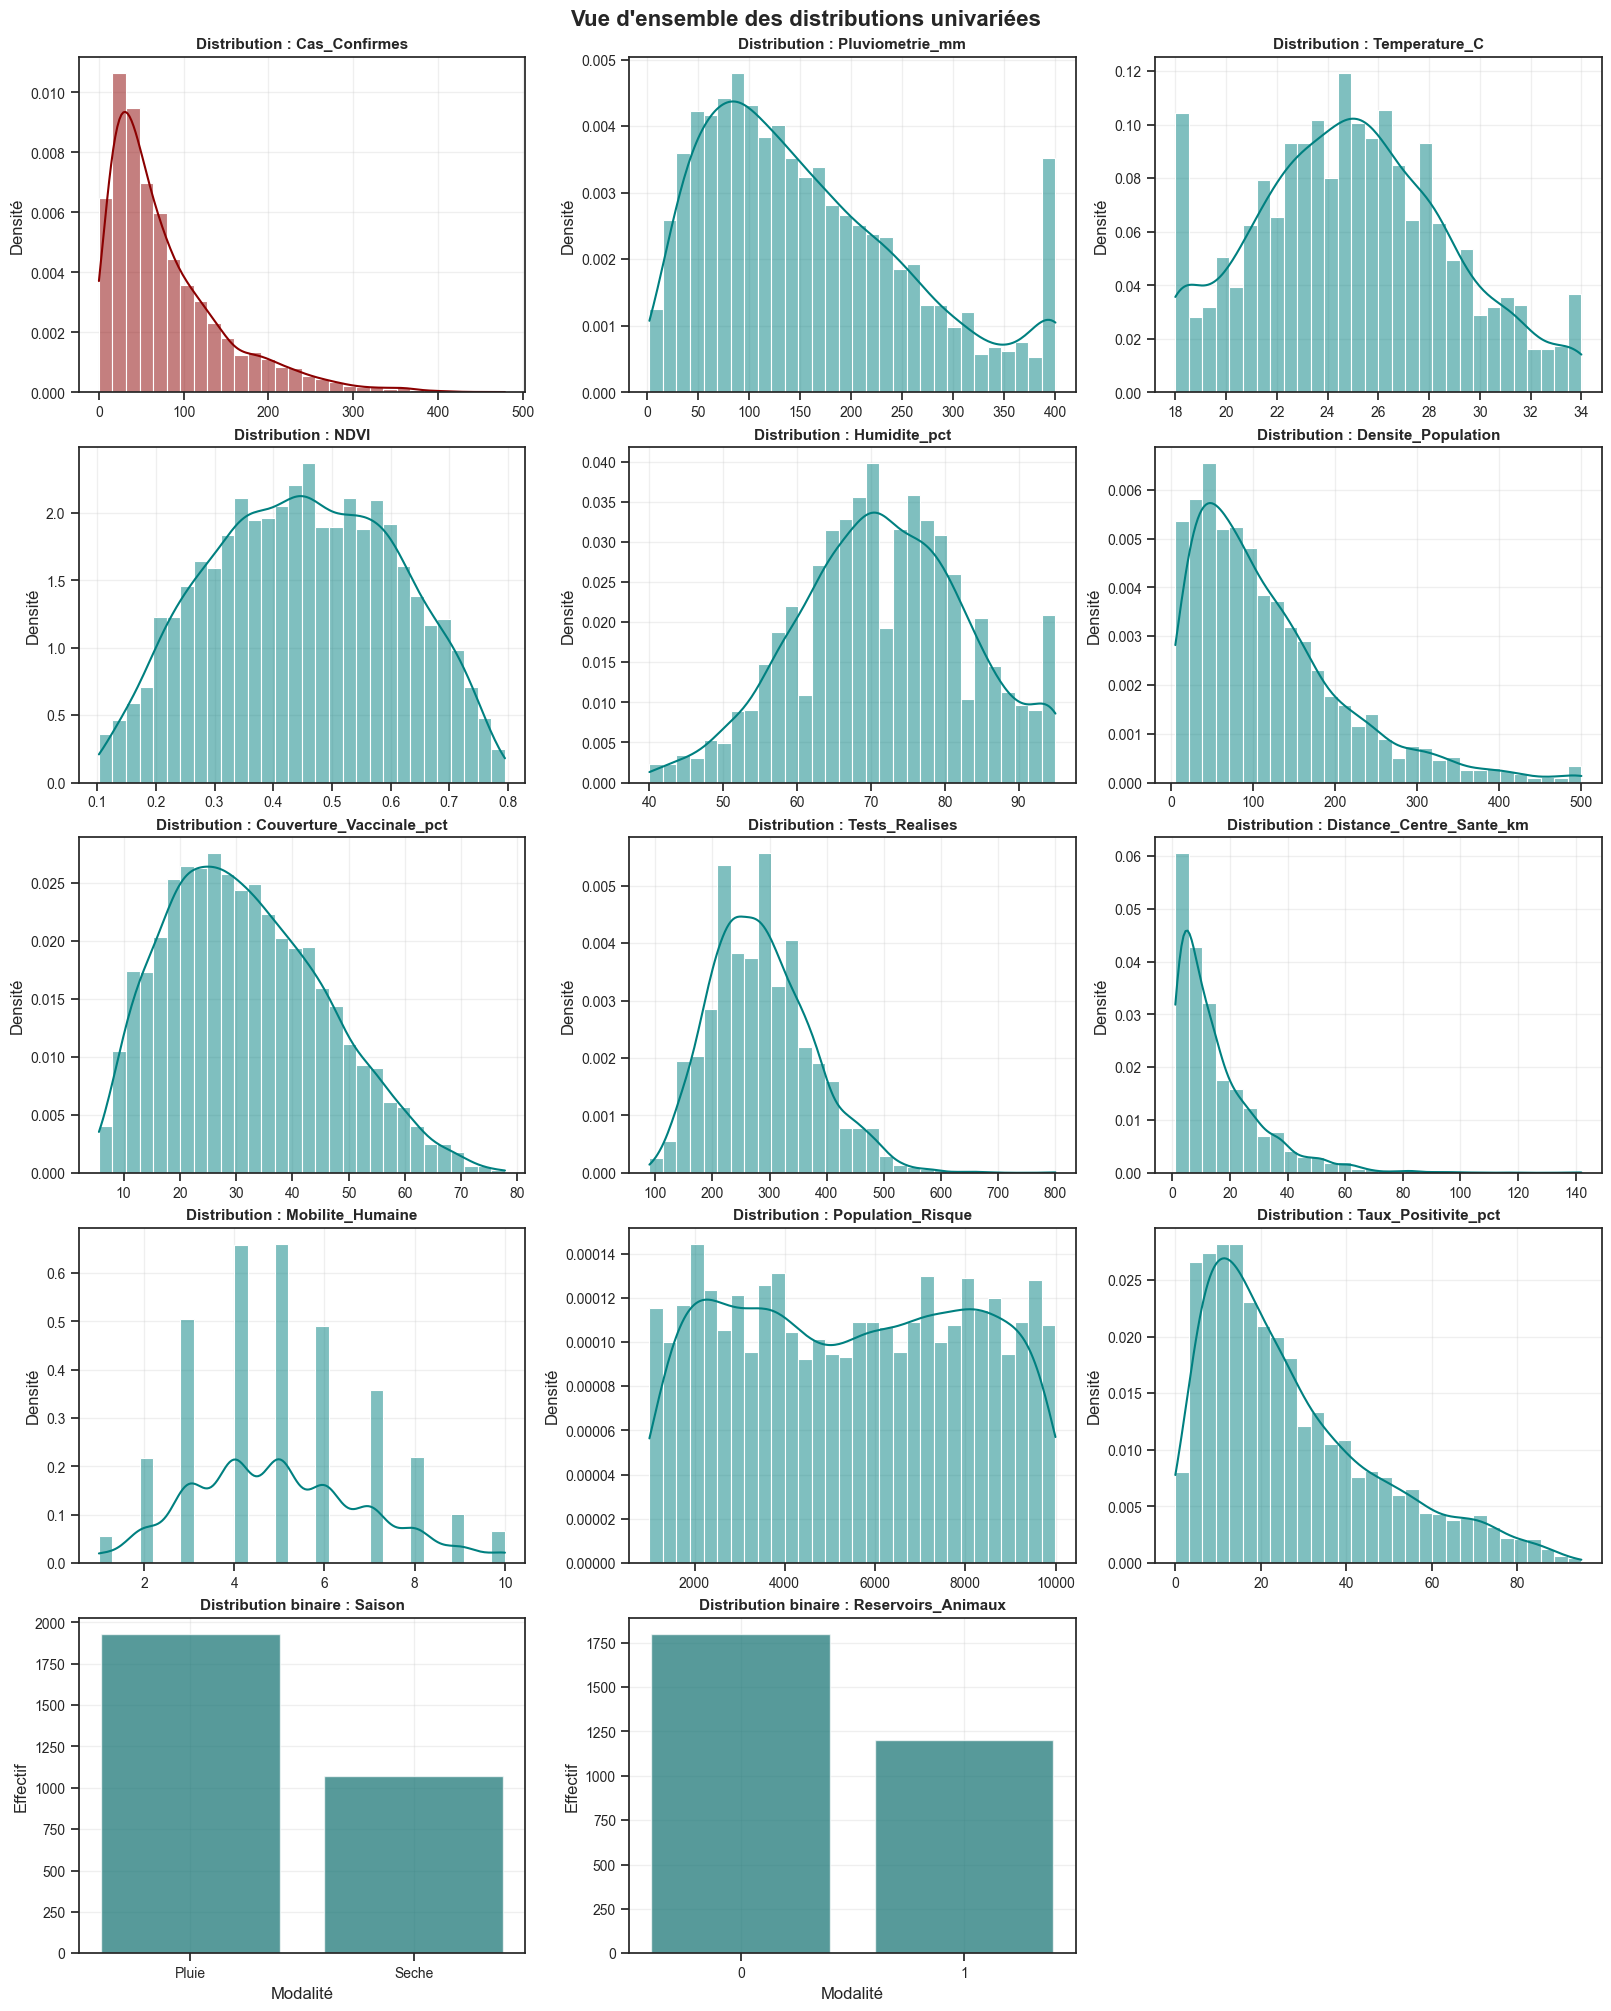

In [77]:
# ================================================================
# AFFICHAGE GLOBAL DES DISTRIBUTIONS (SUBPLOTS)
# ================================================================
#import math

# Variables particulières
VAR_TEMPORELLE = "Semaine"
VAR_CIBLE = "Cas_Confirmes"

VARS_CATEGORIELLES_noprov = [
    col for col in VARS_CATEGORIELLES
    if col != "Province"
]

# Réunir toutes les variables à tracer
toutes_les_vars = (
    [VAR_CIBLE]
    + [col for col in VARS_NUMERIQUES if col != VAR_CIBLE and col != "Semaine"]
    + VARS_CATEGORIELLES_noprov
)

num_vars = len(toutes_les_vars)

# Calcul dynamique du nombre de lignes et colonnes
n_cols = 3
n_rows = math.ceil(num_vars / n_cols)


# Création de la figure
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(16, 4 * n_rows),
    constrained_layout=True
)

fig.suptitle(
    "Vue d'ensemble des distributions univariées",
    fontsize=16,
    fontweight="bold"
)


# Transformer axes en tableau 1D
axes_flat = axes.flatten() if hasattr(axes, "flatten") else [axes]


# Boucle de génération des graphiques
for i, col_name in enumerate(toutes_les_vars):

    ax = axes_flat[i]

    serie = data[col_name].dropna()

    # Couleur spéciale pour la cible
    couleur = "darkred" if col_name == VAR_CIBLE else "teal"


    # =====================================================
    # VARIABLES CATEGORIELLES
    # =====================================================
    if col_name in VARS_CATEGORIELLES_noprov:

        sns.countplot(
            x=serie,
            color=couleur,
            alpha=0.7,
            ax=ax
        )

        ax.set_title(
            f"Distribution binaire : {col_name}",
            fontsize=11,
            fontweight="semibold"
        )

        ax.set_xlabel("Modalité")
        ax.set_ylabel("Effectif")


    # =====================================================
    # VARIABLE QUANTITATIVE OU TEMPORELLE
    # =====================================================
    else:

        sns.histplot(
            serie,
            bins=30,
            kde=True,
            stat="density",
            color=couleur,
            alpha=0.5,
            ax=ax
        )

        ax.set_title(
            f"Distribution : {col_name}",
            fontsize=11,
            fontweight="semibold"
        )

        ax.set_xlabel("")
        ax.set_ylabel("Densité")


    ax.grid(alpha=0.3)


# Masquer les subplots inutilisés
for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)


plt.show()
plt.close()

L'interprétation de ces graphiques est majoritairement similaire à celle donnée au niveau de la synthèse statistiques des données du dataset

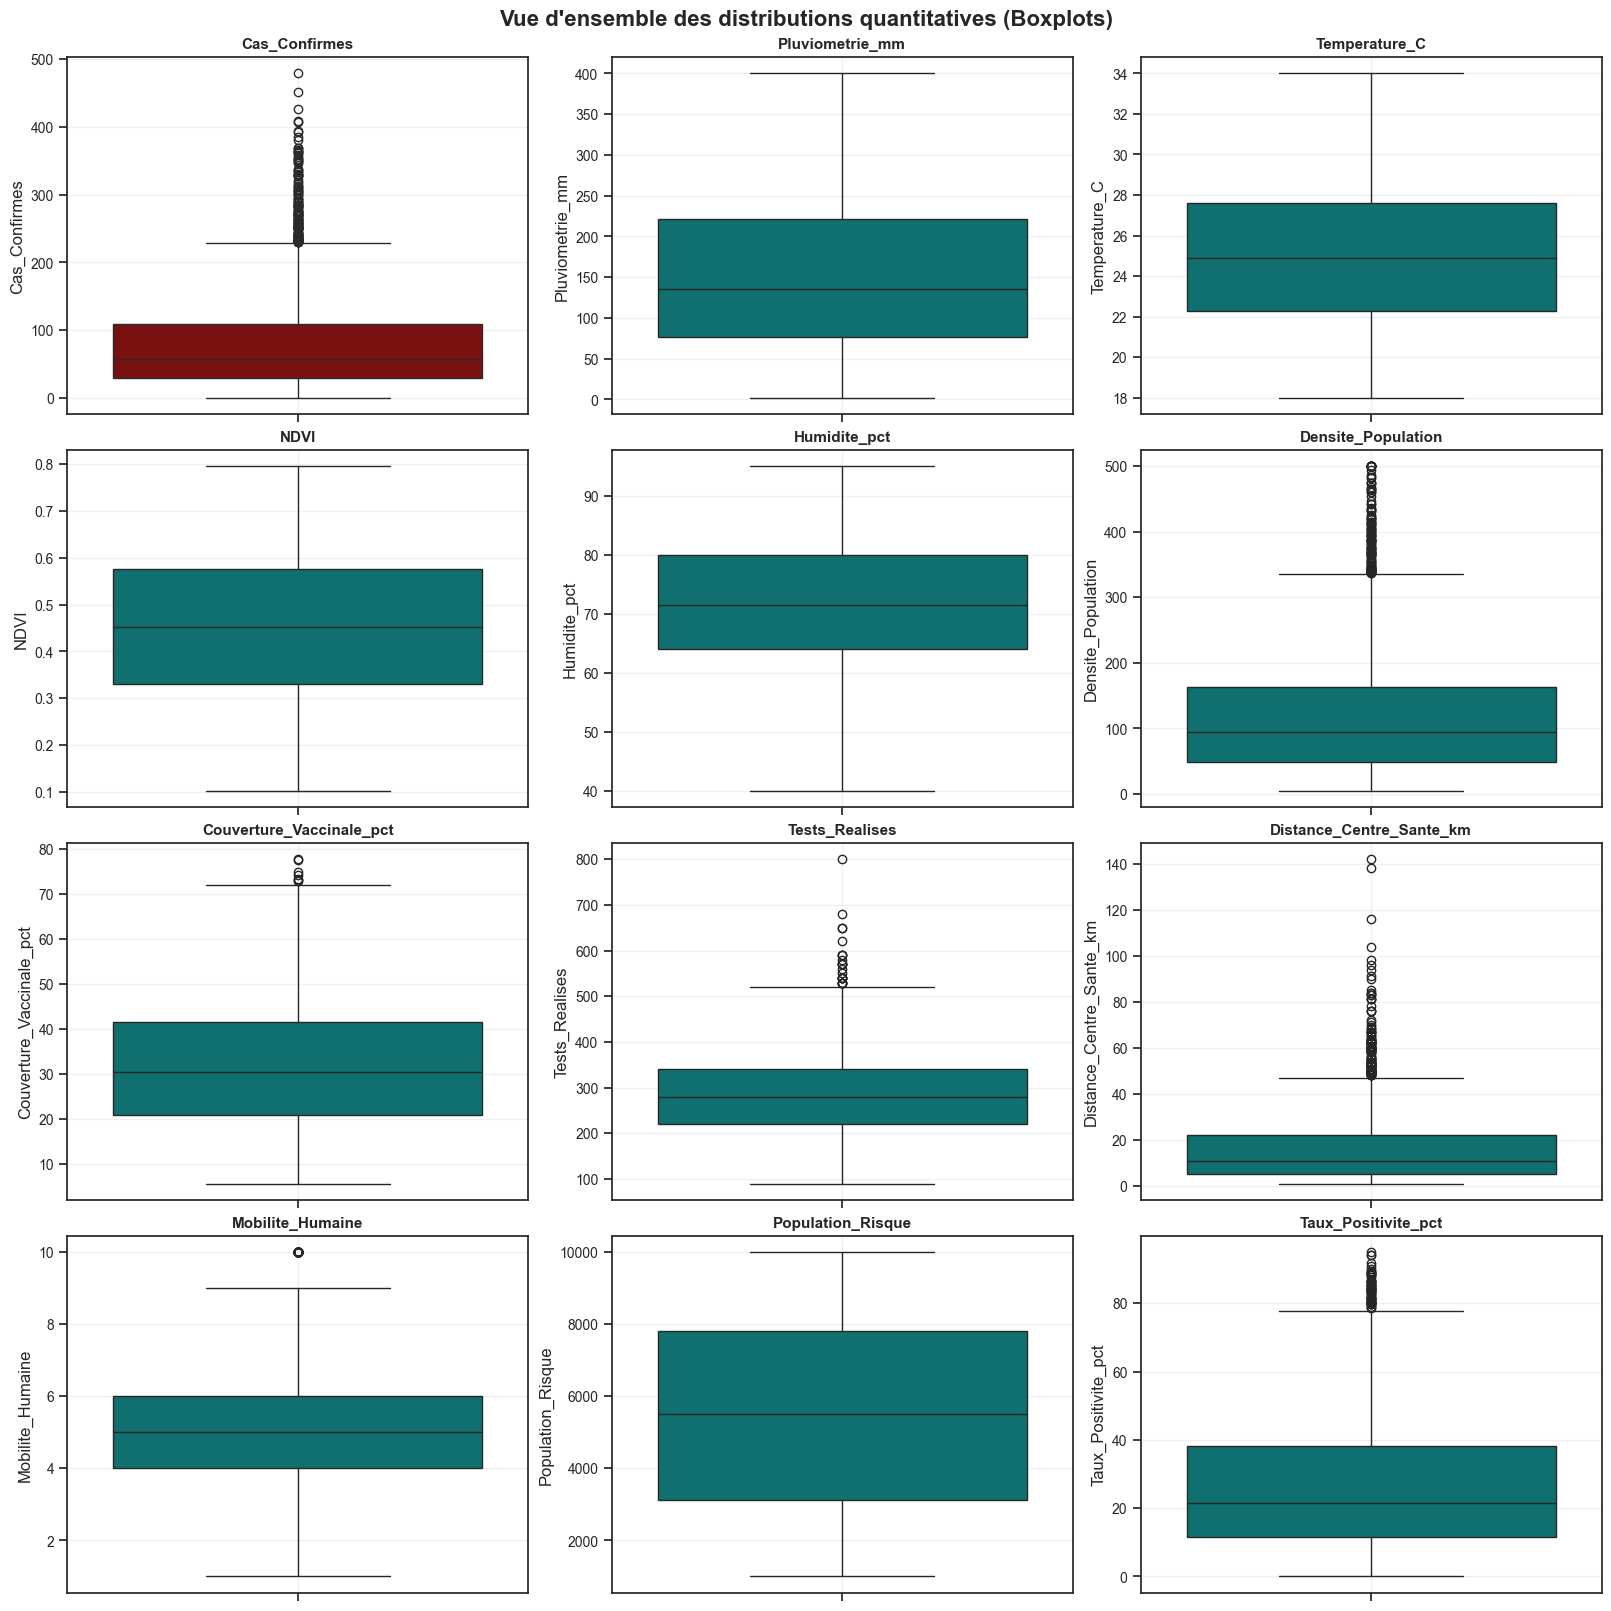

In [78]:
# ================================================================
# AFFICHAGE GLOBAL DES BOXPLOTS VERTICAUX (SUBPLOTS)
# ================================================================
#import math

# Variable cible
VAR_CIBLE = "Cas_Confirmes"


# Variables quantitatives uniquement
VARS_BOX = (
    [VAR_CIBLE]
    + [
        col for col in VARS_NUMERIQUES
        if col != VAR_CIBLE and col != "Semaine"
    ]
)


num_vars = len(VARS_BOX)


# Calcul dynamique du nombre de lignes et colonnes
n_cols = 3
n_rows = math.ceil(num_vars / n_cols)


# Création de la figure
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(16, 4 * n_rows),
    constrained_layout=True
)


fig.suptitle(
    "Vue d'ensemble des distributions quantitatives (Boxplots)",
    fontsize=16,
    fontweight="bold"
)


# Transformer axes en tableau 1D
axes_flat = axes.flatten() if hasattr(axes, "flatten") else [axes]


# Boucle de génération
for i, col_name in enumerate(VARS_BOX):

    ax = axes_flat[i]

    serie = data[col_name].dropna()

    # Couleur spéciale pour la cible
    couleur = "darkred" if col_name == VAR_CIBLE else "teal"


    # Boxplot vertical
    sns.boxplot(
        y=serie,
        color=couleur,
        ax=ax
    )


    ax.set_title(
        f"{col_name}",
        fontsize=11,
        fontweight="semibold"
    )

    ax.set_xlabel("")
    ax.set_ylabel(col_name)

    ax.grid(alpha=0.3)


# Masquer les subplots inutilisés
for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)


plt.show()
plt.close()

De toutes les variables quantitatives, seules la pluviométrie, la température, l'humidité, le NDVI et la population à risque ne présentaient pas de valeurs extrêmes. à une moindre mesure il a été mise en évidence des valeurs extrêmes dans la distribution de la mobilité humaine.
**===========================================================**

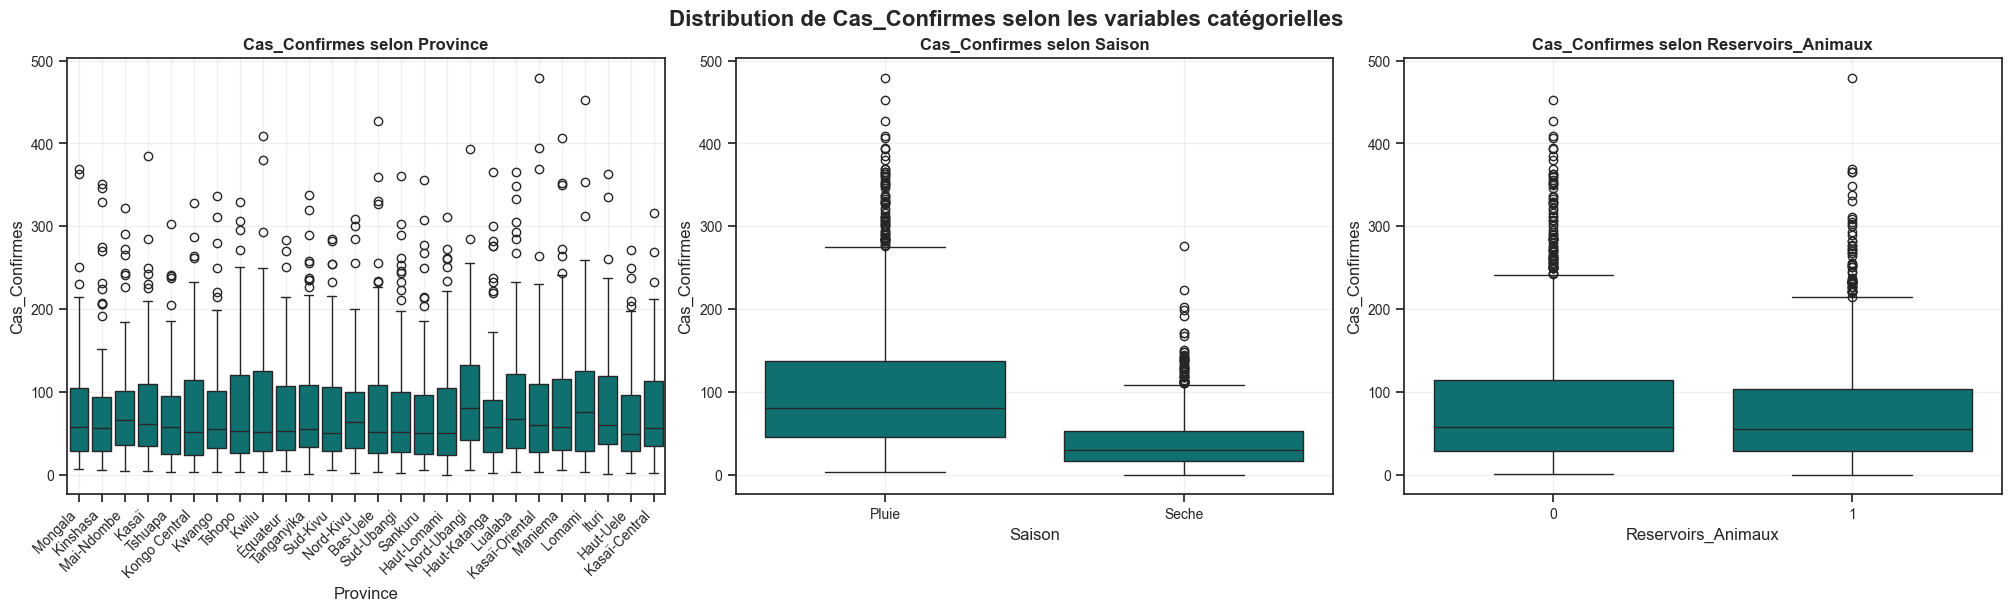

In [79]:
# ================================================================
# BOXPLOTS DE CAS_CONFIRMES SELON LES VARIABLES CATEGORIELLES
# ================================================================

# import matplotlib.pyplot as plt
# import seaborn as sns

# Création figure
fig, axes = plt.subplots(
    1,
    3,
    figsize=(20, 6),
    constrained_layout=True
)


fig.suptitle(
    "Distribution de Cas_Confirmes selon les variables catégorielles",
    fontsize=16,
    fontweight="bold"
)


# Boucle sur les variables
for ax, var in zip(axes, VARS_CATEGORIELLES):

    sns.boxplot(
        data=data,
        x=var,
        y=VAR_CIBLE,
        ax=ax,
        color="teal"
    )

    ax.set_title(
        f"{VAR_CIBLE} selon {var}",
        fontsize=12,
        fontweight="semibold"
    )

    ax.set_xlabel(var)
    ax.set_ylabel(VAR_CIBLE)

    ax.grid(alpha=0.3)


    # Rotation uniquement pour Province
    if var == "Province":
        ax.tick_params(
            axis="x",
            rotation=45
        )

        # Alignement des labels inclinés
        for label in ax.get_xticklabels():
            label.set_horizontalalignment("right")


plt.show()
plt.close()

Le nombre de cas par semaine était approximativement similaire dans tous les provinces. Seulement, plus de cas ont été observés en sainson de pluie qu'en saison sèche mais l'origine de la transmission au même degré d'importance pouvait être d'origine animale ou pas.
**===========================================================**

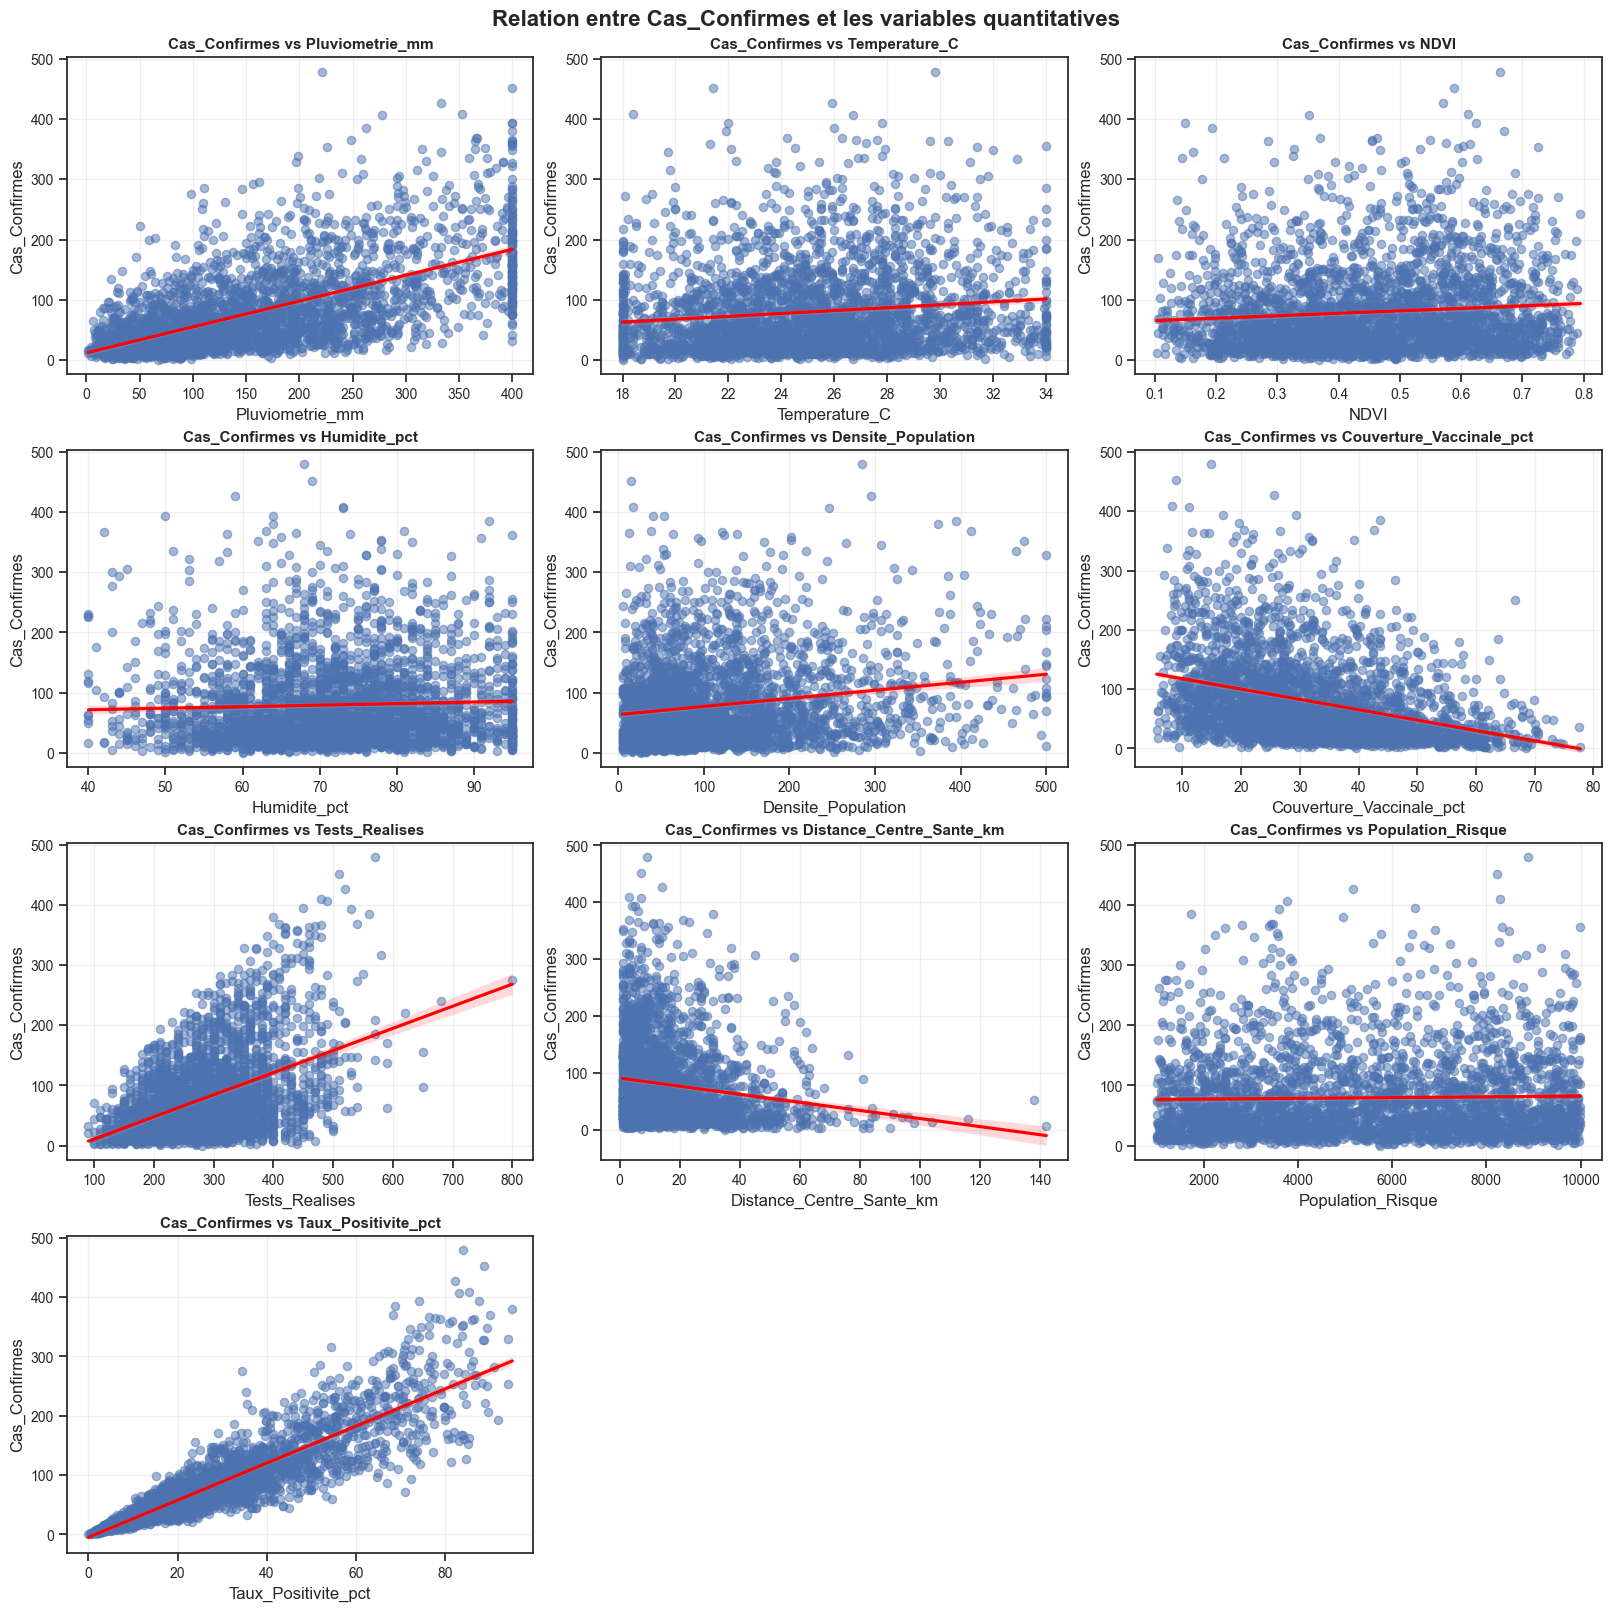

In [80]:
# ================================================================
# SCATTER PLOTS : CAS_CONFIRMES VS VARIABLES QUANTITATIVES
# ================================================================

# import math
# import matplotlib.pyplot as plt
# import seaborn as sns

VAR_CIBLE = "Cas_Confirmes"

# Variables explicatives quantitatives
VARS_SCATTER = [
    col for col in VARS_NUMERIQUES
    if col != VAR_CIBLE and col != "Mobilite_Humaine" and col != "Semaine"
]


num_vars = len(VARS_SCATTER)


# Organisation des subplots
n_cols = 3
n_rows = math.ceil(num_vars / n_cols)


fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(16, 4*n_rows),
    constrained_layout=True
)


fig.suptitle(
    "Relation entre Cas_Confirmes et les variables quantitatives",
    fontsize=16,
    fontweight="bold"
)


axes_flat = axes.flatten() if hasattr(axes, "flatten") else [axes]


# Boucle des scatter plots
for i, col_name in enumerate(VARS_SCATTER):

    ax = axes_flat[i]


    sns.regplot(
        data=data,
        x=col_name,
        y=VAR_CIBLE,
        scatter_kws={
            "alpha":0.5,
            "s":35
        },
        line_kws={
            "color":"red"
        },
        ax=ax
    )


    ax.set_title(
        f"{VAR_CIBLE} vs {col_name}",
        fontsize=11,
        fontweight="semibold"
    )

    ax.set_xlabel(col_name)
    ax.set_ylabel(VAR_CIBLE)

    ax.grid(alpha=0.3)



# Masquer les cases inutilisées
for j in range(i+1, len(axes_flat)):
    axes_flat[j].set_visible(False)


plt.show()
plt.close()

La survenue des cas semble correlée positivement avec le taux de positivité, le nombre de tests realisés et la pluviométrie. à une moindre mesure aussi avec la densité de population, la température, l'humudité relative et la population à risque. A contrario, avec la couverture vaccinale et la distance avec le centre de santé.

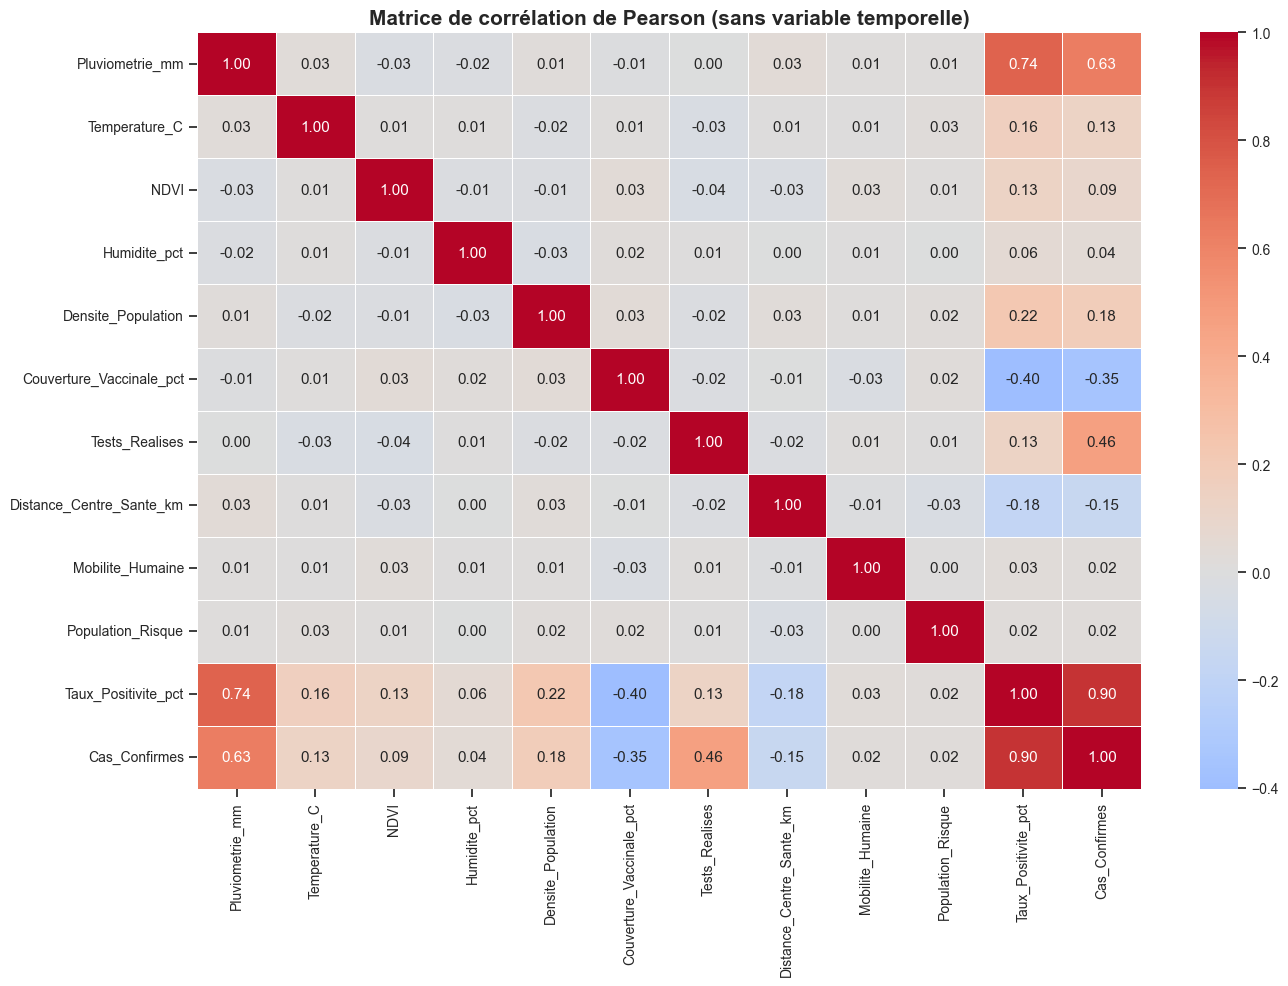

Cas_Confirmes               1.000000
Taux_Positivite_pct         0.899874
Pluviometrie_mm             0.625170
Tests_Realises              0.462248
Densite_Population          0.181571
Temperature_C               0.131251
NDVI                        0.091674
Humidite_pct                0.042544
Mobilite_Humaine            0.024719
Population_Risque           0.022979
Distance_Centre_Sante_km   -0.153797
Couverture_Vaccinale_pct   -0.350440
Name: Cas_Confirmes, dtype: float64

In [81]:
# ================================================================
# MATRICE DE CORRELATION DE PEARSON
# ================================================================

# Variables quantitatives pour corrélation
VARS_CORR = [
    col for col in VARS_NUMERIQUES
    if col not in ["Semaine", "Cas_Confirmes"]
]

# Ajouter la variable cible
VARS_CORR = VARS_CORR + ["Cas_Confirmes"]


corr_matrix = data[VARS_CORR].corr(method="pearson")


plt.figure(figsize=(14,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title(
    "Matrice de corrélation de Pearson (sans variable temporelle)",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

corr_matrix["Cas_Confirmes"].sort_values(ascending=False)

La couverture vaccinale et la distance par rapport au centre de santé sont les 2 seules variables quantitatives présentant un correlation négative par rapport à la survenue des cas de Mpox. plus ces valeurs augmentent, moins de cas il y a. tel que le démontre la matrice de corrélation de Pearson ci-haut.
**===========================================================**

# **3. Encodage des variables catégorielles et NA management**

## **3.1. Variables catégorielles ≤ 2 modalités**

In [82]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

vars_binairies = ["Saison", "Reservoirs_Animaux"]

for k in vars_binairies:
    le = LabelEncoder()
    data[k] = le.fit_transform(data[k])

    mapping = pd.DataFrame({
        "Valeur originale": le.classes_,
        "Code": le.transform(le.classes_)
    })

    print(f"\n=== {k} ===")
    print(mapping)



=== Saison ===
  Valeur originale  Code
0            Pluie     0
1            Seche     1

=== Reservoirs_Animaux ===
   Valeur originale  Code
0                 0     0
1                 1     1


## **3.2. Variables catégorielles > 2 modalités**

In [83]:

data = pd.get_dummies(
    data,
    columns=["Province"],
    drop_first=True
)

In [84]:
data.head()

,ID,Semaine,Pluviometrie_mm,Temperature_C,NDVI,Humidite_pct,Densite_Population,Couverture_Vaccinale_pct,Tests_Realises,Distance_Centre_Sante_km,...,Province_Mongala,Province_Nord-Kivu,Province_Nord-Ubangi,Province_Sankuru,Province_Sud-Kivu,Province_Sud-Ubangi,Province_Tanganyika,Province_Tshopo,Province_Tshuapa,Province_Équateur
0,OBS_00001,1,206,24.4,0.480,64,39,31.8,150,22,...,True,False,False,False,False,False,False,False,False,False
1,OBS_00002,2,56,23.7,0.474,74,107,24.9,300,5,...,False,False,False,False,False,False,False,False,False,False
2,OBS_00003,3,59,25.2,0.333,62,140,53.9,310,16,...,False,False,False,False,False,False,False,False,False,False
3,OBS_00004,4,396,24.1,0.354,68,97,25.9,210,4,...,False,False,False,False,False,False,False,False,False,False
4,OBS_00005,5,127,19.8,0.303,61,86,30.3,260,24,...,False,False,False,False,False,False,False,False,False,False


## **3.3. NA management**

In [85]:
count = data.isnull().sum() # somme des valeurs manquantes

missing_data = count/len(data)*100
print("="*80)
print("Valeurs manquantes ")
print("="*80)
print(missing_data)

Valeurs manquantes 
ID                          0.0
Semaine                     0.0
Pluviometrie_mm             0.0
Temperature_C               0.0
NDVI                        0.0
Humidite_pct                0.0
Densite_Population          0.0
Couverture_Vaccinale_pct    0.0
Tests_Realises              0.0
Distance_Centre_Sante_km    0.0
Reservoirs_Animaux          0.0
Mobilite_Humaine            0.0
Cas_Confirmes               0.0
Saison                      0.0
Population_Risque           0.0
Taux_Positivite_pct         0.0
Province_Haut-Katanga       0.0
Province_Haut-Lomami        0.0
Province_Haut-Uele          0.0
Province_Ituri              0.0
Province_Kasaï              0.0
Province_Kasaï-Central      0.0
Province_Kasaï-Oriental     0.0
Province_Kinshasa           0.0
Province_Kongo Central      0.0
Province_Kwango             0.0
Province_Kwilu              0.0
Province_Lomami             0.0
Province_Lualaba            0.0
Province_Mai-Ndombe         0.0
Province_Maniema    

In [86]:
df_txt = data.select_dtypes(include=["object"])
df_txt.columns

C:\Users\hp\AppData\Local\Temp\ipykernel_46928\1346937900.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_txt = data.select_dtypes(include=["object"])


Index(['ID'], dtype='str')

- Aucune des variables ne contient de valeurs manquantes
- tiutes les variables étaient numériques exceptés ID, Saison et Province. Ces deux dernières ont été encodées avec labelEncoder

# **4. Normalisation MinMax**

In [87]:
print(data["Reservoirs_Animaux"].dtype)

int64


In [88]:
data.columns

Index(['ID', 'Semaine', 'Pluviometrie_mm', 'Temperature_C', 'NDVI',
       'Humidite_pct', 'Densite_Population', 'Couverture_Vaccinale_pct',
       'Tests_Realises', 'Distance_Centre_Sante_km', 'Reservoirs_Animaux',
       'Mobilite_Humaine', 'Cas_Confirmes', 'Saison', 'Population_Risque',
       'Taux_Positivite_pct', 'Province_Haut-Katanga', 'Province_Haut-Lomami',
       'Province_Haut-Uele', 'Province_Ituri', 'Province_Kasaï',
       'Province_Kasaï-Central', 'Province_Kasaï-Oriental',
       'Province_Kinshasa', 'Province_Kongo Central', 'Province_Kwango',
       'Province_Kwilu', 'Province_Lomami', 'Province_Lualaba',
       'Province_Mai-Ndombe', 'Province_Maniema', 'Province_Mongala',
       'Province_Nord-Kivu', 'Province_Nord-Ubangi', 'Province_Sankuru',
       'Province_Sud-Kivu', 'Province_Sud-Ubangi', 'Province_Tanganyika',
       'Province_Tshopo', 'Province_Tshuapa', 'Province_Équateur'],
      dtype='str')

In [89]:
from sklearn.preprocessing import MinMaxScaler

# Colonnes exclues de la normalisation
colonnes_exclues = [
    'ID', 'Semaine', 'Reservoirs_Animaux', 'Saison', 'Cas_Confirmes',
    'Province_Haut-Katanga', 'Province_Haut-Lomami',
    'Province_Haut-Uele', 'Province_Ituri', 'Province_Kasaï',
    'Province_Kasaï-Central', 'Province_Kasaï-Oriental',
    'Province_Kinshasa', 'Province_Kongo Central', 'Province_Kwango',
    'Province_Kwilu', 'Province_Lomami', 'Province_Lualaba',
    'Province_Mai-Ndombe', 'Province_Maniema', 'Province_Mongala',
    'Province_Nord-Kivu', 'Province_Nord-Ubangi', 'Province_Sankuru',
    'Province_Sud-Kivu', 'Province_Sud-Ubangi', 'Province_Tanganyika',
    'Province_Tshopo', 'Province_Tshuapa', 'Province_Équateur'
] # exclusion de Y des variables à normaliser

# Séparation
data2 = data.drop(columns=colonnes_exclues)
data_exclues = data[colonnes_exclues]

# Normalisation MinMax
minmax = MinMaxScaler()
data2_min = minmax.fit_transform(data2)

data2_scaler = pd.DataFrame(
    data2_min,
    columns = data2.columns,
    index = data.index      # conserver les mêmes indices pour la fututre fusion
)


In [90]:
# Fusion
data3_scaler = pd.concat([data_exclues, data2_scaler], axis=1)

# (Optionnel) remettre l'ordre des colonnes identique à celui du DataFrame initial
data3_scaler = data3_scaler[data.columns]

data3_scaler.head()

,ID,Semaine,Pluviometrie_mm,Temperature_C,NDVI,Humidite_pct,Densite_Population,Couverture_Vaccinale_pct,Tests_Realises,Distance_Centre_Sante_km,...,Province_Mongala,Province_Nord-Kivu,Province_Nord-Ubangi,Province_Sankuru,Province_Sud-Kivu,Province_Sud-Ubangi,Province_Tanganyika,Province_Tshopo,Province_Tshuapa,Province_Équateur
0,OBS_00001,1,0.512563,0.40000,0.544798,0.436364,0.068687,0.362881,0.084507,0.148936,...,True,False,False,False,False,False,False,False,False,False
1,OBS_00002,2,0.135678,0.35625,0.536127,0.618182,0.206061,0.267313,0.295775,0.028369,...,False,False,False,False,False,False,False,False,False,False
2,OBS_00003,3,0.143216,0.45000,0.332370,0.400000,0.272727,0.668975,0.309859,0.106383,...,False,False,False,False,False,False,False,False,False,False
3,OBS_00004,4,0.989950,0.38125,0.362717,0.509091,0.185859,0.281163,0.169014,0.021277,...,False,False,False,False,False,False,False,False,False,False
4,OBS_00005,5,0.314070,0.11250,0.289017,0.381818,0.163636,0.342105,0.239437,0.163121,...,False,False,False,False,False,False,False,False,False,False


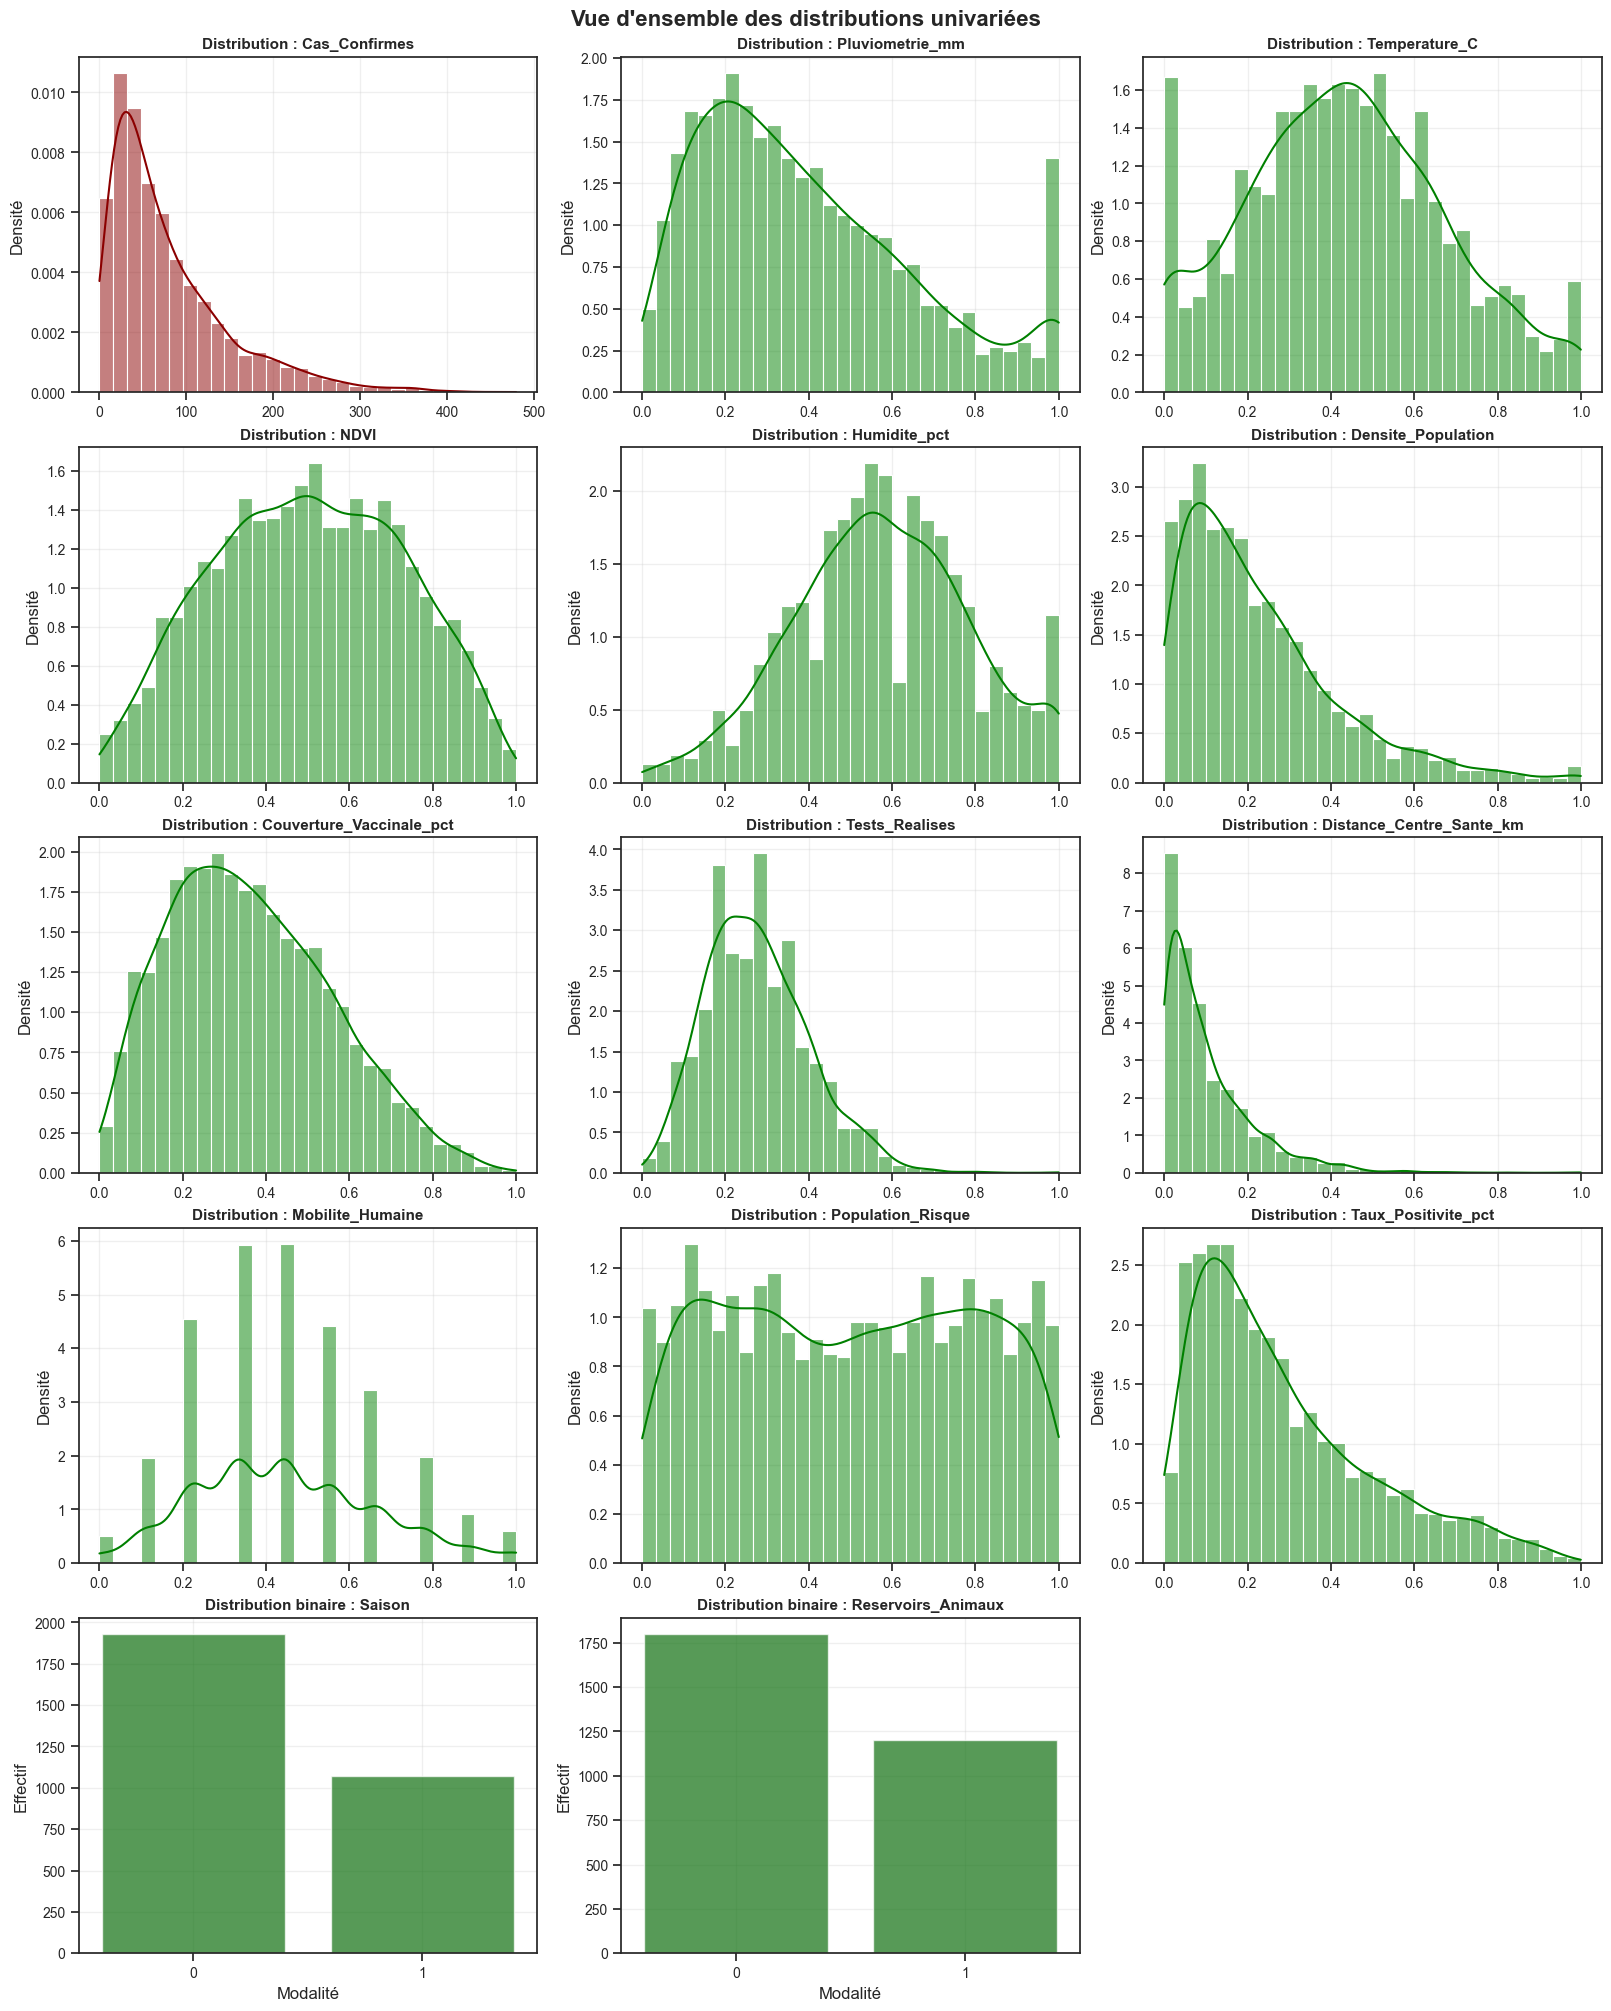

In [91]:
# ================================================================
# AFFICHAGE GLOBAL DES DISTRIBUTIONS APRES NORMALISATION (SUBPLOTS)
# ================================================================
#import math

# Variables particulières
VAR_TEMPORELLE = "Semaine"
VAR_CIBLE = "Cas_Confirmes"

VARS_CATEGORIELLES_noprov = [
    col for col in VARS_CATEGORIELLES
    if col != "Province"
]

# Réunir toutes les variables à tracer
toutes_les_vars = (
    [VAR_CIBLE]
    + [col for col in VARS_NUMERIQUES if col != VAR_CIBLE and col != "Semaine"]
    + VARS_CATEGORIELLES_noprov
)

num_vars = len(toutes_les_vars)

# Calcul dynamique du nombre de lignes et colonnes
n_cols = 3
n_rows = math.ceil(num_vars / n_cols)


# Création de la figure
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(16, 4 * n_rows),
    constrained_layout=True
)

fig.suptitle(
    "Vue d'ensemble des distributions univariées",
    fontsize=16,
    fontweight="bold"
)


# Transformer axes en tableau 1D
axes_flat = axes.flatten() if hasattr(axes, "flatten") else [axes]


# Boucle de génération des graphiques
for i, col_name in enumerate(toutes_les_vars):

    ax = axes_flat[i]

    serie = data3_scaler[col_name].dropna()

    # Couleur spéciale pour la cible
    couleur = "darkred" if col_name == VAR_CIBLE else "green"


    # =====================================================
    # VARIABLES CATEGORIELLES
    # =====================================================
    if col_name in VARS_CATEGORIELLES_noprov:

        sns.countplot(
            x=serie,
            color=couleur,
            alpha=0.7,
            ax=ax
        )

        ax.set_title(
            f"Distribution binaire : {col_name}",
            fontsize=11,
            fontweight="semibold"
        )

        ax.set_xlabel("Modalité")
        ax.set_ylabel("Effectif")


    # =====================================================
    # VARIABLE QUANTITATIVE OU TEMPORELLE
    # =====================================================
    else:

        sns.histplot(
            serie,
            bins=30,
            kde=True,
            stat="density",
            color=couleur,
            alpha=0.5,
            ax=ax
        )

        ax.set_title(
            f"Distribution : {col_name}",
            fontsize=11,
            fontweight="semibold"
        )

        ax.set_xlabel("")
        ax.set_ylabel("Densité")


    ax.grid(alpha=0.3)


# Masquer les subplots inutilisés
for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)


plt.show()
plt.close()

- Ci-haut les distributions des différentes variables après normalisation. les valeurs abérrantes sont maintenues mais toutes les variables quantitatives ont été ramenées à la même unité avec comme minimum 0 et maximum 1.
- Cas_Confirmes a été exclu de la normalisation pour permettre de conserver son unité et de faciliter l'interprétation.

# **5. Spliting dataset (Y = 0.75 | X = 0.25)**

In [92]:
data3_scaler = data3_scaler.drop(columns = 'ID')

In [93]:
excluded_vars = ['Semaine','Taux_Positivite_pct']

X = data3_scaler.drop(columns=['Cas_Confirmes']) # exclusion de Y
X = X.drop(columns = excluded_vars)

y = data3_scaler['Cas_Confirmes']

**Nous avons exclus 4 variables de la liste des variables explicatives (X) :**
- ID puisque ne represente que l'identifiant
- Cas_Confirmes puisque c'est la variable à expliquer (Y)
- Semaine puisqu'elle représente la variable temporelle d'évolution de la variable à expliquer et des covariables
- Taux_Positivite_pct puisqu'elle est fortement correlée à l'incidence des cas. Seuls les cas ayant été déclarés positifs sont dits cas confirmés.

In [94]:
X.head()

,Pluviometrie_mm,Temperature_C,NDVI,Humidite_pct,Densite_Population,Couverture_Vaccinale_pct,Tests_Realises,Distance_Centre_Sante_km,Reservoirs_Animaux,Mobilite_Humaine,...,Province_Mongala,Province_Nord-Kivu,Province_Nord-Ubangi,Province_Sankuru,Province_Sud-Kivu,Province_Sud-Ubangi,Province_Tanganyika,Province_Tshopo,Province_Tshuapa,Province_Équateur
0,0.512563,0.40000,0.544798,0.436364,0.068687,0.362881,0.084507,0.148936,1,0.333333,...,True,False,False,False,False,False,False,False,False,False
1,0.135678,0.35625,0.536127,0.618182,0.206061,0.267313,0.295775,0.028369,1,0.555556,...,False,False,False,False,False,False,False,False,False,False
2,0.143216,0.45000,0.332370,0.400000,0.272727,0.668975,0.309859,0.106383,0,0.777778,...,False,False,False,False,False,False,False,False,False,False
3,0.989950,0.38125,0.362717,0.509091,0.185859,0.281163,0.169014,0.021277,0,1.000000,...,False,False,False,False,False,False,False,False,False,False
4,0.314070,0.11250,0.289017,0.381818,0.163636,0.342105,0.239437,0.163121,1,0.555556,...,False,False,False,False,False,False,False,False,False,False


In [95]:
y.head()

0    29
1    42
2    20
3    82
4    24
Name: Cas_Confirmes, dtype: int64

In [96]:
x_train, x_test, y_train, y_test = \
    train_test_split(X, y, test_size=0.25, random_state=22)

**========================================================================================**
**INTERPRETATION DES MODELES**
**========================================================================================**
-	Convergences
    - Non significatifs dans les 2 modèles : Population à risque, 
    - Significatifs : 
        - Positif : densité population, tests réalisés, 
        - Négatif : couverture vaccinale, distance par rapport au centre de santé, 
    - R² ≥ 0,80 : Les deux modèles expliquent très bien la variabilité observée des cas confirmés. OLS (RMSE = 30,62 ; MAE = 22,30) | Poisson (RMSE = 27,74 ; MAE = 17,53) : Le modèle de Poisson présente une meilleure capacité prédictive, avec des erreurs de prédiction plus faibles.
-	Divergences
    - OLS
        - Significatifs : Reservoirs animaux, Saison (+)
        - Non significatifs : Mobilité humaine
            - Poisson
                - Significatifs : Mobilité humaine, Saison (-)
                - Non significatifs : Reservoirs animaux
-	Cas particuliers : Le modèle de Poisson met davantage en évidence les différences géographiques entre provinces.
-	Déviance/ddl ≈ 5,7 ; Pearson/ddl ≈ 5,7 : Le modèle de Poisson présente une forte surdispersion, ce qui remet en cause l'une de ses hypothèses fondamentales.
-	Pertinence méthodologique : Le modèle de Poisson est plus approprié que l'OLS pour des données de comptage, mais un modèle binomial négatif serait encore plus adapté.


# **6. Ordinary Least Square (OLS)**

In [97]:
model_LRM = LinearRegression()
model_LRM.fit(x_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](37,)","[178.38, 38.18, 43.45,..., -1.6 , -5.87, -4.99]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](37,)","['Pluviometrie_mm','Temperature_C','NDVI',...,'Province_Tshopo', 'Province_Tshuapa','Province_Équateur']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-68.87
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,37
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,37


In [98]:
b0 = model_LRM.intercept_
print('Intercept : ', b0)

Intercept :  -68.87173706887964


In [99]:
coef = model_LRM.coef_
coef

array([ 1.78380149e+02,  3.81807056e+01,  4.34507861e+01,  2.04247655e+01,
        7.21454651e+01, -1.24825955e+02,  2.59063482e+02, -1.12332337e+02,
       -1.51786694e+00, -2.36528436e+00,  6.40491582e+00,  8.12520404e-01,
       -5.36560126e+00, -3.88025077e+00, -3.38146445e+00, -1.07386054e+00,
       -3.79027318e+00, -1.00315288e+01,  3.26687187e+00, -4.59900263e+00,
       -3.61026668e-01, -6.46165671e+00,  2.26783612e-01,  2.55448405e+00,
       -8.41113845e-01, -4.51765833e+00, -3.36732487e-01, -8.07992766e+00,
       -7.78002409e+00, -5.74260134e+00, -1.08788939e+01, -6.13553348e+00,
       -2.81052356e+00, -2.62926740e+00, -1.60047683e+00, -5.86831299e+00,
       -4.98550169e+00])

In [100]:
y_pred = model_LRM.predict(x_test)
# y_pred

In [101]:
print("MSE",mean_squared_error(y_test, y_pred))
print("MAE",mean_absolute_error(y_test, y_pred))
print("RMSE",math.sqrt(mean_squared_error(y_test, y_pred)))
print("R²", r2_score(y_test, y_pred) )

MSE 854.8780725131192
MAE 22.12987889887017
RMSE 29.238298044057203
R² 0.8273857874081861


In [102]:
print(X_train.dtypes)
print("\nColonnes object :")
print(X_train.select_dtypes(include=["object"]).columns)

print("\nType Y :")
print(y_train.dtype)

Pluviometrie_mm             float64
Temperature_C               float64
NDVI                        float64
Humidite_pct                float64
Densite_Population          float64
Couverture_Vaccinale_pct    float64
Tests_Realises              float64
Distance_Centre_Sante_km    float64
Reservoirs_Animaux            int64
Mobilite_Humaine            float64
Saison                        int64
Population_Risque           float64
Province_Haut-Katanga          bool
Province_Haut-Lomami           bool
Province_Haut-Uele             bool
Province_Ituri                 bool
Province_Kasaï                 bool
Province_Kasaï-Central         bool
Province_Kasaï-Oriental        bool
Province_Kinshasa              bool
Province_Kongo Central         bool
Province_Kwango                bool
Province_Kwilu                 bool
Province_Lomami                bool
Province_Lualaba               bool
Province_Mai-Ndombe            bool
Province_Maniema               bool
Province_Mongala            

Dimensions X : (3000, 37)
Dimension Y : (3000,)
                            OLS Regression Results                            
Dep. Variable:          Cas_Confirmes   R-squared:                       0.824
Model:                            OLS   Adj. R-squared:                  0.821
Method:                 Least Squares   F-statistic:                     298.5
Date:                Mon, 20 Jul 2026   Prob (F-statistic):               0.00
Time:                        16:35:32   Log-Likelihood:                -11494.
No. Observations:                2400   AIC:                         2.306e+04
Df Residuals:                    2362   BIC:                         2.328e+04
Df Model:                          37                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------

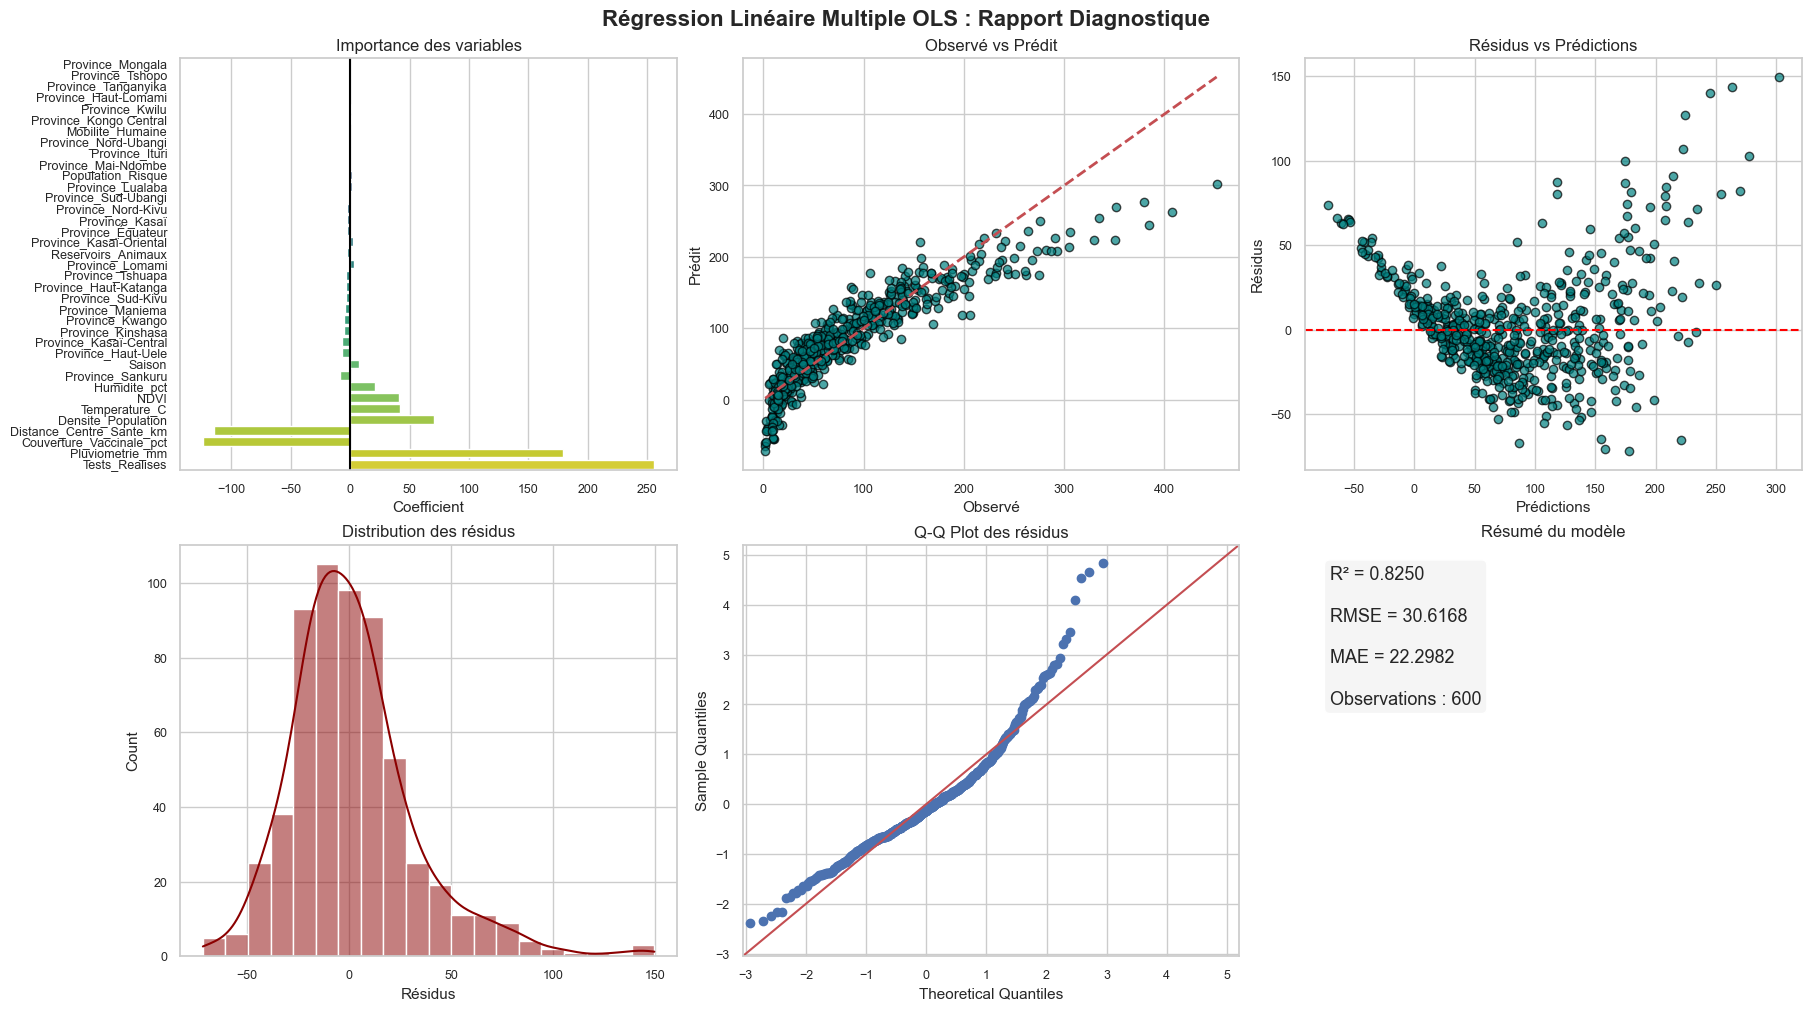

In [103]:
# =============================================================================
# RÉGRESSION LINÉAIRE MULTIPLE OLS - PLANCHE DE SUBPLOTS ACADÉMIQUE (ÉPURÉE)
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Configuration esthétique globale
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9
})

# =============================================================================
# 1. DEFINITION X ET Y
# =============================================================================
if 'data3_scaler' not in locals() and 'data3_scaler' not in globals():
    print("[INFO] Génération d'un DataFrame fictif 'data3_scaler' pour exécution...")
    np.random.seed(42)
    n_samples = 500
    data3_scaler = pd.DataFrame({
        'Pluviometrie_mm': np.random.randn(n_samples),
        'Temperature_C': np.random.randn(n_samples),
        'NDVI': np.random.randn(n_samples),
        'Humidite_pct': np.random.randn(n_samples),
        'Semaine': np.random.randint(1, 53, size=n_samples),
        'Taux_Positivite_pct': np.random.randn(n_samples),
        'Cas_Confirmes': np.random.randn(n_samples)
    })

X = data3_scaler.drop(columns=['Cas_Confirmes', 'Semaine', 'Taux_Positivite_pct'])
y = data3_scaler["Cas_Confirmes"]

print("Dimensions X :", X.shape)
print("Dimension Y :", y.shape)

# =============================================================================
# 2. TRAITEMENTS ET CALCULS STATISTIQUES
# =============================================================================
# Division Train / Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modèle Sklearn & Prédictions
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Calcul des résidus (Échantillon Test)
residus = y_test - y_pred

# Modèle OLS Statsmodels pour l'inférence textuelle
# Conversion complète en numérique pour Statsmodels
X_train_ols = X_train.astype(float)
y_train_ols = y_train.astype(float)

# Ajout constante
X_train_sm = sm.add_constant(X_train_ols)

# Modèle OLS
ols_model = sm.OLS(
    y_train_ols,
    X_train_sm
).fit()

print(ols_model.summary())

# Affichage des métriques de performance textuelles
print("\n================ PERFORMANCE MODELE ================")
print(f"R²   : {r2_score(y_test, y_pred):.4f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.4f}")
print("====================================================\n")
print(ols_model.summary())

# =============================================================================
# 3. RAPPORT GRAPHIQUE OLS (5 SUBPLOTS + METRIQUES)
# =============================================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)
fig.suptitle(
    "Régression Linéaire Multiple OLS : Rapport Diagnostique",
    fontsize=16,
    fontweight="bold",
)

# ------------------------------------------------------------------
# 1. Importance des variables
# ------------------------------------------------------------------
importance = pd.DataFrame({"Variable": X.columns, "Coefficient": model.coef_})

importance["Importance"] = importance["Coefficient"].abs()
importance = importance.sort_values("Importance", ascending=True)

sns.barplot(
    data=importance,
    x="Coefficient",
    y="Variable",
    hue="Variable",
    palette="viridis",
    legend=False,
    ax=axes[0, 0],
)

axes[0, 0].axvline(0, color="black")
axes[0, 0].set_title("Importance des variables")
axes[0, 0].set_xlabel("Coefficient")
axes[0, 0].set_ylabel("")

# ------------------------------------------------------------------
# 2. Valeurs observées vs prédites
# ------------------------------------------------------------------
axes[0, 1].scatter(
    y_test, y_pred, alpha=0.7, color="teal", edgecolor="black"
)

axes[0, 1].plot(
    [y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2
)

axes[0, 1].set_title("Observé vs Prédit")
axes[0, 1].set_xlabel("Observé")
axes[0, 1].set_ylabel("Prédit")

# ------------------------------------------------------------------
# 3. Résidus vs prédictions
# ------------------------------------------------------------------
axes[0, 2].scatter(
    y_pred, residus, alpha=0.7, color="teal", edgecolor="black"
)

axes[0, 2].axhline(0, color="red", linestyle="--")

axes[0, 2].set_title("Résidus vs Prédictions")
axes[0, 2].set_xlabel("Prédictions")
axes[0, 2].set_ylabel("Résidus")

# ------------------------------------------------------------------
# 4. Distribution des résidus
# ------------------------------------------------------------------
sns.histplot(residus, kde=True, bins=20, color="darkred", ax=axes[1, 0])

axes[1, 0].set_title("Distribution des résidus")
axes[1, 0].set_xlabel("Résidus")

# ------------------------------------------------------------------
# 5. Q-Q Plot
# ------------------------------------------------------------------
sm.qqplot(residus, line="45", fit=True, ax=axes[1, 1])

axes[1, 1].set_title("Q-Q Plot des résidus")

# ------------------------------------------------------------------
# 6. Dernière case : métriques du modèle
# ------------------------------------------------------------------
axes[1, 2].axis("off")

texte = (
    f"R² = {r2_score(y_test, y_pred):.4f}\n\n"
    f"RMSE = {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}\n\n"
    f"MAE = {mean_absolute_error(y_test, y_pred):.4f}\n\n"
    f"Observations : {len(y_test)}"
)

axes[1, 2].text(
    0.05,
    0.95,
    texte,
    fontsize=13,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="whitesmoke"),
)

axes[1, 2].set_title("Résumé du modèle")

plt.show()

## **7. RLM - Poisson**

## **7.0. Booléens à Binaire**

In [106]:
bool_cols = X.select_dtypes(include="bool").columns
X[bool_cols] = X[bool_cols].astype(int)

## **7.1. test d'hétéroscedasticité**

In [107]:
# =============================================================================
# TEST DE BREUSCH-PAGAN (Hétéroscédasticité)
# =============================================================================
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

bp_test = het_breuschpagan(
    ols_model.resid,      # Résidus du modèle
    ols_model.model.exog  # Matrice des variables explicatives
)

bp_results = pd.DataFrame({
    "Statistique": [
        "LM Statistic",
        "LM p-value",
        "F Statistic",
        "F p-value"
    ],
    "Valeur": bp_test
})

print("\n================ TEST DE BREUSCH-PAGAN ================\n")
print(bp_results.to_string(index=False))

alpha = 0.05

if bp_test[1] < alpha:
    print("\nConclusion :")
    print("→ Rejet de H0 (p < 0,05)")
    print("→ Présence d'une hétéroscédasticité significative.")
else:
    print("\nConclusion :")
    print("→ H0 non rejetée (p ≥ 0,05)")
    print("→ Aucune preuve d'hétéroscédasticité.")


================ TEST DE BREUSCH-PAGAN ================

 Statistique       Valeur
LM Statistic 3.159808e+02
  LM p-value 5.452395e-46
 F Statistic 9.679150e+00
   F p-value 7.517121e-50

Conclusion :
→ Rejet de H0 (p < 0,05)
→ Présence d'une hétéroscédasticité significative.


## **7.2. Regression de Poisson**

<>:276: SyntaxWarning: invalid escape sequence '\h'
<>:298: SyntaxWarning: invalid escape sequence '\h'
<>:276: SyntaxWarning: invalid escape sequence '\h'
<>:298: SyntaxWarning: invalid escape sequence '\h'
C:\Users\hp\AppData\Local\Temp\ipykernel_46928\2734034731.py:276: SyntaxWarning: invalid escape sequence '\h'
  axes[0, 1].set_ylabel("Prédictions ($\hat{\lambda}_{\text{test}}$)")
C:\Users\hp\AppData\Local\Temp\ipykernel_46928\2734034731.py:298: SyntaxWarning: invalid escape sequence '\h'
  axes[0, 2].set_xlabel("Prédictions ($\hat{\lambda}_{\text{train}}$)")


Dimensions X : (3000, 37)
Dimension Y : (3000,)
====== VÉRIFICATION DE LA VALIDITÉ DES DONNÉES ======
[OK] Toutes les conditions de validité des données sont respectées.

Dimensions X : (3000, 37)
Dimension Y : (3000,)

================ PERFORMANCE ET ADÉQUATION DU MODÈLE ================
Log-Likelihood (Modèle complet) : -13751.3282
Log-Likelihood (Modèle Nul)    : -70068.3172
Test du rapport de vraisemblance : LRT=112633.9782, ddl=37, p-value=0.0000e+00
AIC                              : 27578.6563
BIC (basé sur log-vraisemblance) : 27798.4188
Déviance Résiduelle             : 13539.1650
Déviance Nulle                  : 126173.1432
Pseudo-R² (McFadden)             : 0.8037
RMSE (Échantillon Test)          : 27.7420
MAE (Échantillon Test)           : 17.5321
MAPE (Cas > 0 - Échantillon Test) : 34.47 %

                 Generalized Linear Model Regression Results                  
Dep. Variable:          Cas_Confirmes   No. Observations:                 2400
Model:                    

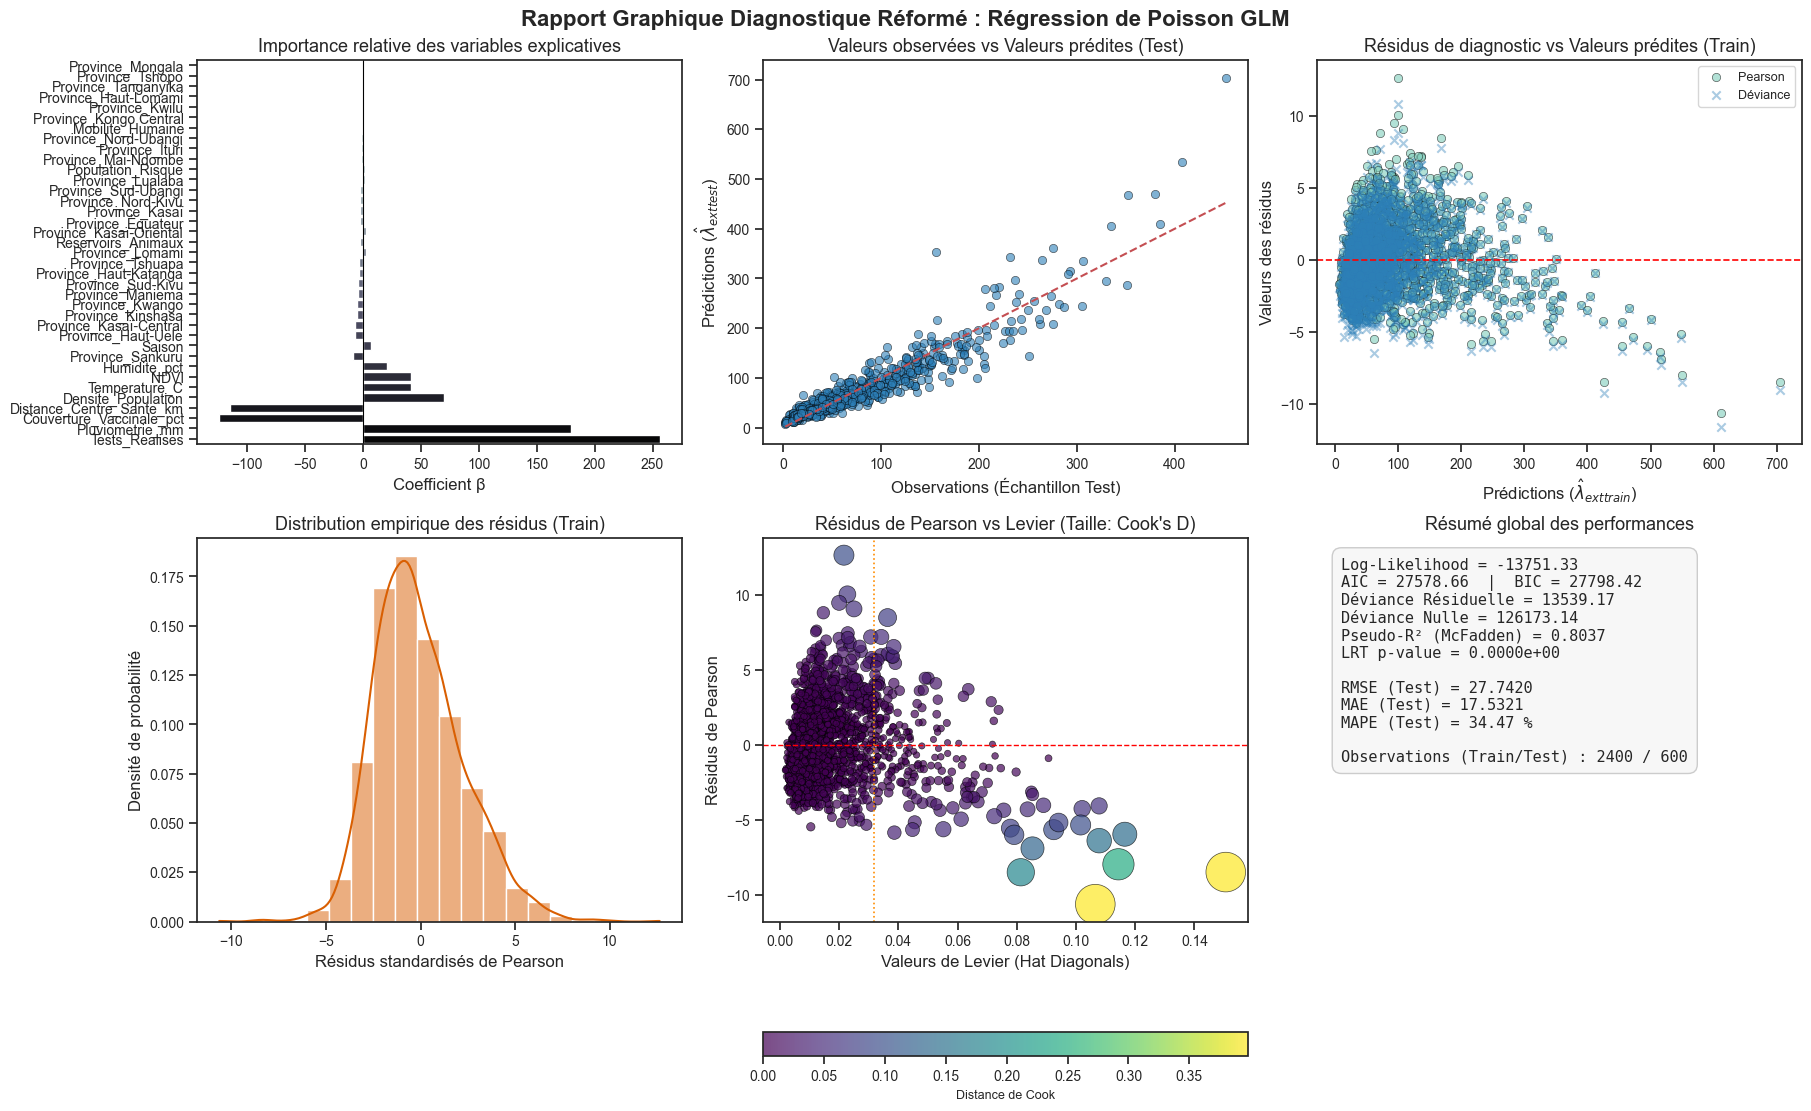


================ DIAGNOSTICS APPROFONDIS DE SURDISPERSION ================
Degrés de liberté résiduels : 2362
Rapport de Dispersion (Déviance / ddl) : 5.7321
Rapport de Dispersion (Pearson Chi² / ddl) : 5.6889
p-value du test de bonté d'ajustement (Chi² de Pearson) : 0.0000

Interprétation statistique du critère de dispersion :
 -> Ratio (5.69) > 1.5 : Présence confirmée d'une surdispersion forte.
 -> [AVERTISSEMENT] Le test de Pearson rejette l'adéquation stricte à la loi de Poisson (p < 0.05).

!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
[ALERTE ACTIONNABLE] ALGORITHME ALTERNATIF RECOMMANDÉ
Les conditions d'équidispersion sous-jacentes à la distribution de Poisson sont violées.
Pour éviter l'effondrement des erreurs standards et l'inflation des faux positifs (Erreur Type I),
il est requis d'ajuster une structure GLM Binomiale Négative (NB2) comme suit :
     >>> import statsmodels.formula.api as smf
     >>> nb2_model = sm.GLM(y_train, X_train_sm

In [111]:
# =============================================================================
# RÉGRESSION DE POISSON GLM - ANALYSE DIAGNOSTIQUE & RAPPORT ÉPIDÉMIOLOGIQUE
# =============================================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

# Configuration esthétique globale (Standard Académique / Publication)
sns.set_theme(style="ticks")
plt.rcParams.update(
    {
        "font.size": 11,
        "axes.labelsize": 12,
        "axes.titlesize": 13,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "figure.titlesize": 15,
    }
)

# =============================================================================
# 1. DEFINITION X ET Y & VALIDATION DES DONNÉES
# =============================================================================
if "data3_scaler" not in locals() and "data3_scaler" not in globals():
    print("[INFO] Génération d'un DataFrame fictif 'data3_scaler' adapté à Poisson...")
    np.random.seed(42)
    n_samples = 500
    # Génération de prédicteurs
    X_fictif = np.random.randn(n_samples, 4)
    # Simulation d'un processus de Poisson log-linéaire : lambda = exp(Xb)
    lambda_param = np.exp(
        0.5 + 0.3 * X_fictif[:, 0] - 0.2 * X_fictif[:, 1] + 0.1 * X_fictif[:, 2]
    )
    y_fictif = np.random.poisson(lam=lambda_param)

    data3_scaler = pd.DataFrame(
        {
            "Pluviometrie_mm": X_fictif[:, 0],
            "Temperature_C": X_fictif[:, 1],
            "NDVI": X_fictif[:, 2],
            "Humidite_pct": X_fictif[:, 3],
            "Semaine": np.random.randint(1, 53, size=n_samples),
            "Taux_Positivite_pct": np.random.randn(n_samples),
            "Cas_Confirmes": y_fictif,  # Doit être des entiers >= 0
        }
    )

X = data3_scaler.drop(columns=['Cas_Confirmes', 'Semaine', 'Taux_Positivite_pct'])
y = data3_scaler["Cas_Confirmes"]

# Conversion des variables booléennes (One-Hot) en 0/1
bool_cols = X.select_dtypes(include="bool").columns
X[bool_cols] = X[bool_cols].astype(int)

print("Dimensions X :", X.shape)
print("Dimension Y :", y.shape)

# --- BLOC DE VÉRIFICATION STRICTE DES DONNÉES ---
print("====== VÉRIFICATION DE LA VALIDITÉ DES DONNÉES ======")
assert np.issubdtype(
    y.dtype, np.integer
), "[ERREUR] La variable cible Y doit être composée d'entiers."
assert (
    y >= 0
).all(), "[ERREUR] La variable cible Y ne doit pas contenir de valeurs négatives."
assert (
    not X.isna().any().any() and not y.isna().any()
), "[ERREUR] Présence de valeurs manquantes (NaN) détectée."
assert np.isfinite(X).all().all() and np.isfinite(
    y
).all(), "[ERREUR] Présence de valeurs infinies (inf) détectée."
assert all(
    np.issubdtype(X[col].dtype, np.number) for col in X.columns
), "[ERREUR] Toutes les variables explicatives X doivent être numériques."
print("[OK] Toutes les conditions de validité des données sont respectées.\n")

print("Dimensions X :", X.shape)
print("Dimension Y :", y.shape)

# =============================================================================
# 2. TRAITEMENTS ET CALCULS STATISTIQUES
# =============================================================================
# Division Train / Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Ajout de la constante pour statsmodels
X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)

# Ajustement du modèle complet (GLM Poisson) sur le TRAIN
poisson_model = sm.GLM(
    y_train, X_train_sm, family=sm.families.Poisson()
).fit()

# Ajustement du modèle nul (Intercept seul) sur le TRAIN pour le calcul du Pseudo-R²
poisson_null = sm.GLM(
    y_train,
    np.ones((len(y_train), 1)),
    family=sm.families.Poisson(),
).fit()

# Prédictions disjointes et rigoureuses
y_pred_train = poisson_model.predict(X_train_sm)
y_pred_test = poisson_model.predict(X_test_sm)

# Diagnostics de résidus basés exclusivement sur l'échantillon d'ENTRAÎNEMENT
residus_pearson_train = poisson_model.resid_pearson
residus_deviance_train = poisson_model.resid_deviance

# Extraction des diagnostics d'influence (Échantillon d'Entraînement)
infl = poisson_model.get_influence()
leverage_train = infl.hat_matrix_diag
cooks_d_train, _ = infl.cooks_distance

# Métriques globales exactes du modèle (Train)
log_lik = poisson_model.llf
log_lik_null = poisson_null.llf
aic = poisson_model.aic
bic = poisson_model.bic_llf  # BIC ajusté sur la log-vraisemblance
deviance = poisson_model.deviance
null_deviance = poisson_model.null_deviance

# Calcul du Pseudo-R² de McFadden
pseudo_r2_mcfadden = 1 - (log_lik / log_lik_null)

# Test du rapport de vraisemblance (Likelihood Ratio Test)
lrt_stat = 2 * (log_lik - log_lik_null)
lrt_df = poisson_model.df_model
lrt_pvalue = stats.chi2.sf(lrt_stat, lrt_df)

# Métriques d'erreur prédictive sur l'échantillon TEST uniquement
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_test = mean_absolute_error(y_test, y_pred_test)

# Erreur absolue moyenne en pourcentage (sur les observations non nulles du Test)
mask_nonzero_test = y_test > 0
mape_test = (
    np.mean(
        np.abs(y_test[mask_nonzero_test] - y_pred_test[mask_nonzero_test])
        / y_test[mask_nonzero_test]
    )
    * 100
)

# Affichage des métriques de performance textuelles globales
print("\n================ PERFORMANCE ET ADÉQUATION DU MODÈLE ================")
print(f"Log-Likelihood (Modèle complet) : {log_lik:.4f}")
print(f"Log-Likelihood (Modèle Nul)    : {log_lik_null:.4f}")
print(
    f"Test du rapport de vraisemblance : LRT={lrt_stat:.4f}, ddl={lrt_df}, p-value={lrt_pvalue:.4e}"
)
print(f"AIC                              : {aic:.4f}")
print(f"BIC (basé sur log-vraisemblance) : {bic:.4f}")
print(f"Déviance Résiduelle             : {deviance:.4f}")
print(f"Déviance Nulle                  : {null_deviance:.4f}")
print(f"Pseudo-R² (McFadden)             : {pseudo_r2_mcfadden:.4f}")
print(f"RMSE (Échantillon Test)          : {rmse_test:.4f}")
print(f"MAE (Échantillon Test)           : {mae_test:.4f}")
print(f"MAPE (Cas > 0 - Échantillon Test) : {mape_test:.2f} %")
print("=====================================================================\n")
print(poisson_model.summary())

# =============================================================================
# 3. TABLEAU D'INTERPRÉTATION DES COEFFICIENTS & IRR
# =============================================================================
print(
    "\n================ TABLEAU DES ESTIMATIONS ET INCIDENCE RATE RATIOS (IRR) ================"
)
df_coefs = pd.DataFrame(
    {
        "Coefficient β": poisson_model.params,
        "Erreur Standard": poisson_model.bse,
        "z": poisson_model.tvalues,
        "p-value": poisson_model.pvalues,
    }
)

# Calcul des Intervalles de Confiance à 95% pour les coefficients et les IRR
conf_int = poisson_model.conf_int()
df_coefs["IC95% inférieur"] = conf_int[0]
df_coefs["IC95% supérieur"] = conf_int[1]
df_coefs["IRR = exp(β)"] = np.exp(df_coefs["Coefficient β"])
df_coefs["IRR IC95% inf"] = np.exp(conf_int[0])
df_coefs["IRR IC95% sup"] = np.exp(conf_int[1])

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)
print(df_coefs.round(4))

print("\n--- Interprétation automatisée des IRR (Variables Explicatives) ---")
for var in X.columns:
    beta = df_coefs.loc[var, "Coefficient β"]
    irr = df_coefs.loc[var, "IRR = exp(β)"]
    p_val = df_coefs.loc[var, "p-value"]
    sig_status = (
        "statistiquement significative"
        if p_val < 0.05
        else "non significative"
    )

    if beta >= 0:
        pct = (irr - 1) * 100
        print(
            f" - {var} ({sig_status}) : Une augmentation d'une unité de cette variable est associée à une "
            f"augmentation de {pct:.1f} % du nombre attendu de cas, toutes choses égales par ailleurs."
        )
    else:
        pct = (1 - irr) * 100
        print(
            f" - {var} ({sig_status}) : Une augmentation d'une unité de cette variable est associée à une "
            f"diminution de {pct:.1f} % du nombre attendu de cas, toutes choses égales par ailleurs."
        )

# =============================================================================
# 4. RAPPORT GRAPHIQUE ACADÉMIQUE RETRAVAILLÉ (PLANCHE DE 6 SUBPLOTS)
# =============================================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 11), constrained_layout=True)
fig.suptitle(
    "Rapport Graphique Diagnostique Réformé : Régression de Poisson GLM",
    fontsize=16,
    fontweight="bold",
)

# Subplot 1 : Importance des variables (Train) - Coefficients Éliminant l'Intercept
importance = pd.DataFrame({
    "Variable": X_train_ols.columns,
    "Coefficient": ols_model.params.drop("const").values
})

# retirer la constante
importance = importance[importance["Variable"] != "const"]

importance["Importance"] = importance["Coefficient"].abs()

importance = importance.sort_values(
    "Importance",
    ascending=True
)

sns.barplot(
    data=importance,
    x="Coefficient",
    y="Variable",
    hue="Variable",
    palette="bone_r",
    legend=False,
    ax=axes[0, 0],
)
axes[0, 0].axvline(0, color="black", linestyle="-", lw=0.8)
axes[0, 0].set_title("Importance relative des variables explicatives")
axes[0, 0].set_xlabel("Coefficient β")
axes[0, 0].set_ylabel("")

# Subplot 2 : Valeurs observées vs Valeurs prédites (Exclusif Jeu de Test)
axes[0, 1].scatter(
    y_test,
    y_pred_test,
    alpha=0.6,
    color="#2c7fb8",
    edgecolor="black",
    linewidth=0.5,
)
axes[0, 1].plot(
    [y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=1.5
)
axes[0, 1].set_title("Valeurs observées vs Valeurs prédites (Test)")
axes[0, 1].set_xlabel("Observations (Échantillon Test)")
axes[0, 1].set_ylabel("Prédictions ($\hat{\lambda}_{\text{test}}$)")

# Subplot 3 : Résidus vs Valeurs prédites (Exclusif Jeu d'Entraînement)
axes[0, 2].scatter(
    y_pred_train,
    residus_pearson_train,
    alpha=0.6,
    color="#7fcdbb",
    edgecolor="black",
    linewidth=0.5,
    label="Pearson",
)
axes[0, 2].scatter(
    y_pred_train,
    residus_deviance_train,
    alpha=0.4,
    color="#2c7fb8",
    marker="x",
    label="Déviance",
)
axes[0, 2].axhline(0, color="red", linestyle="--", lw=1.2)
axes[0, 2].set_title("Résidus de diagnostic vs Valeurs prédites (Train)")
axes[0, 2].set_xlabel("Prédictions ($\hat{\lambda}_{\text{train}}$)")
axes[0, 2].set_ylabel("Valeurs des résidus")
axes[0, 2].legend(frameon=True, fontsize=9)

# Subplot 4 : Distribution des résidus de Pearson (Train)
sns.histplot(
    residus_pearson_train,
    kde=True,
    bins=20,
    color="#d95f02",
    ax=axes[1, 0],
    stat="density",
)
axes[1, 0].set_title("Distribution empirique des résidus (Train)")
axes[1, 0].set_xlabel("Résidus standardisés de Pearson")
axes[1, 0].set_ylabel("Densité de probabilité")

# Subplot 5 : Graphique Diagnostic d'Influence et de Levier Combiné (Train)
scatter_infl = axes[1, 1].scatter(
    leverage_train,
    residus_pearson_train,
    s=cooks_d_train * 2000 + 20,  # Taille proportionnelle à la distance de Cook
    c=cooks_d_train,
    cmap="viridis",
    alpha=0.7,
    edgecolor="black",
    linewidth=0.5,
)
axes[1, 1].axhline(0, color="red", linestyle="--", lw=1)
leverage_threshold = 2 * (X_train_sm.shape[1]) / len(X_train)
axes[1, 1].axvline(
    leverage_threshold,
    color="darkorange",
    linestyle=":",
    lw=1.2,
    label="Seuil Levier",
)
axes[1, 1].set_title("Résidus de Pearson vs Levier (Taille: Cook's D)")
axes[1, 1].set_xlabel("Valeurs de Levier (Hat Diagonals)")
axes[1, 1].set_ylabel("Résidus de Pearson")
cbar = fig.colorbar(scatter_infl, ax=axes[1, 1], orientation="horizontal", pad=0.15)
cbar.set_label("Distance de Cook", fontsize=9)

# Subplot 6 : Résumé métrique épuré et complet
axes[1, 2].axis("off")
texte_box = (
    f"Log-Likelihood = {log_lik:.2f}\n"
    f"AIC = {aic:.2f}  |  BIC = {bic:.2f}\n"
    f"Déviance Résiduelle = {deviance:.2f}\n"
    f"Déviance Nulle = {null_deviance:.2f}\n"
    f"Pseudo-R² (McFadden) = {pseudo_r2_mcfadden:.4f}\n"
    f"LRT p-value = {lrt_pvalue:.4e}\n\n"
    f"RMSE (Test) = {rmse_test:.4f}\n"
    f"MAE (Test) = {mae_test:.4f}\n"
    f"MAPE (Test) = {mape_test:.2f} %\n\n"
    f"Observations (Train/Test) : {len(y_train)} / {len(y_test)}"
)
axes[1, 2].text(
    0.05,
    0.95,
    texte_box,
    fontsize=11,
    verticalalignment="top",
    fontname="monospace",
    bbox=dict(
        boxstyle="round,pad=0.6", facecolor="#f7f7f7", edgecolor="#cccccc"
    ),
)
axes[1, 2].set_title("Résumé global des performances")

plt.show()

# =============================================================================
# 5. DIAGNOSTICS DE SURDISPERSION EXHAUSTIFS
# =============================================================================
print(
    "\n================ DIAGNOSTICS APPROFONDIS DE SURDISPERSION ================"
)
df_resid = poisson_model.df_resid
dispersion_deviance = deviance / df_resid
pearson_chi2 = poisson_model.pearson_chi2
dispersion_pearson = pearson_chi2 / df_resid

print(f"Degrés de liberté résiduels : {df_resid}")
print(f"Rapport de Dispersion (Déviance / ddl) : {dispersion_deviance:.4f}")
print(f"Rapport de Dispersion (Pearson Chi² / ddl) : {dispersion_pearson:.4f}")

# Évaluation formelle de l'adéquation globale par les résidus
p_val_adequation = 1 - stats.chi2.cdf(pearson_chi2, df_resid)
print(
    f"p-value du test de bonté d'ajustement (Chi² de Pearson) : {p_val_adequation:.4f}"
)

hypothese_valide = True
print("\nInterprétation statistique du critère de dispersion :")
if dispersion_pearson < 1.0:
    print(
        f" -> Ratio ({dispersion_pearson:.2f}) < 1.0 : Signe potentiel de sous-dispersion."
    )
elif 1.0 <= dispersion_pearson <= 1.15:
    print(
        f" -> Ratio ({dispersion_pearson:.2f}) ≈ 1.0 : Hypothèse fondamentale d'équidispersion validée."
    )
elif 1.15 < dispersion_pearson <= 1.5:
    print(
        f" -> Ratio ({dispersion_pearson:.2f}) > 1.15 : Présence d'une surdispersion modérée."
    )
else:
    print(
        f" -> Ratio ({dispersion_pearson:.2f}) > 1.5 : Présence confirmée d'une surdispersion forte."
    )
    hypothese_valide = False

if p_val_adequation < 0.05:
    print(
        " -> [AVERTISSEMENT] Le test de Pearson rejette l'adéquation stricte à la loi de Poisson (p < 0.05)."
    )
    hypothese_valide = False
else:
    print(
        " -> [OK] Pas de divergence significative face aux hypothèses de la loi de Poisson."
    )

# Bloc correctif automatique si violation des hypothèses de Poisson
if not hypothese_valide:
    print("\n" + "!" * 80)
    print("[ALERTE ACTIONNABLE] ALGORITHME ALTERNATIF RECOMMANDÉ")
    print(
        "Les conditions d'équidispersion sous-jacentes à la distribution de Poisson sont violées."
    )
    print(
        "Pour éviter l'effondrement des erreurs standards et l'inflation des faux positifs (Erreur Type I),"
    )
    print(
        "il est requis d'ajuster une structure GLM Binomiale Négative (NB2) comme suit :"
    )
    print("     >>> import statsmodels.formula.api as smf")
    print(
        "     >>> nb2_model = sm.GLM(y_train, X_train_sm, family=sm.families.NegativeBinomial()).fit()"
    )
    print("!" * 80 + "\n")

# =============================================================================
# 6. SYNTHÈSE ET INTERPRÉTATION AUTOMATIQUE FINALE (FRANÇAIS)
# =============================================================================
print(
    "\n================ RAPPORT STATISTIQUE SYNTHÉTIQUE (STYLE PUBLICATION) ================"
)
converged = poisson_model.converged
status_convergence = (
    "a convergé avec succès" if converged else "n'a PAS convergé"
)

variables_significatives = (
    df_coefs.index[df_coefs["p-value"] < 0.05]
    .drop("const", errors="ignore")
    .tolist()
)
risques_eleves = (
    df_coefs.index[(df_coefs["p-value"] < 0.05) & (df_coefs["Coefficient β"] > 0)]
    .drop("const", errors="ignore")
    .tolist()
)
risques_reduits = (
    df_coefs.index[(df_coefs["p-value"] < 0.05) & (df_coefs["Coefficient β"] < 0)]
    .drop("const", errors="ignore")
    .tolist()
)

nb_sig = len(variables_significatives)

synthese = (
    f"1. Convergence du modèle : L'algorithme d'estimation par maximum de vraisemblance {status_convergence}.\n"
    f"2. Évaluation du modèle vs Modèle nul : Le test du rapport de vraisemblance s'avère hautement significatif "
    f"(p = {lrt_pvalue:.4e}), indiquant que l'introduction des covariables améliore significativement l'ajustement.\n"
    f"3. Analyse de la dispersion : Le paramètre de dispersion basé sur le Chi² de Pearson est égal à {dispersion_pearson:.3f}. "
)

if not hypothese_valide:
    synthese += (
        "On note une anomalie de dispersion remettant en cause l'égalité théorique moyenne/variance. "
        "Une modélisation alternative via une régression binomiale négative (NB2) doit être envisagée "
        "pour corriger l'inflation du risque de première espèce.\n"
    )
else:
    synthese += (
        "La variance observée reste compatible avec la structure de la loi de Poisson (équidispersion relative). "
        "Le modèle de Poisson standard est structurellement adapté aux données.\n"
    )

synthese += (
    f"4. Profil de significativité : Sur les {len(X.columns)} covariables analysées, {nb_sig} manifestent un effet "
    f"statistiquement significatif à l'alpha de 5% ({', '.join(variables_significatives) if nb_sig > 0 else 'Aucune'}).\n"
)

if len(risques_eleves) > 0:
    synthese += f"   - Facteur(s) associé(s) à une hausse de l'incidence : {', '.join(risques_eleves)}.\n"
if len(risques_reduits) > 0:
    synthese += f"   - Facteur(s) associé(s) à une baisse de l'incidence : {', '.join(risques_reduits)}.\n"

print(synthese)
print(
    "====================================================================================="
)